# Basic Synthesis
First and foremost, get mean and stddev for quiz scores, as well as differences between pretest and posttest.

In [1]:
#Make all of the dataframes from the files
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

preDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/pretest.csv')
postDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/posttest.csv')
idDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/ids.csv')

#Normalize some stuff
preDF['nav_total'] = preDF['nav_total']/2
preDF['reorganize_total'] = preDF['reorganize_total']/3
preDF['match_total'] = preDF['match_total']/4
preDF['newfolder_total'] = preDF['newfolder_total']/3
preDF['total'] = preDF['total']/12

postDF['nav_total'] = postDF['nav_total']/2
postDF['reorganize_total'] = postDF['reorganize_total']/3
postDF['match_total'] = postDF['match_total']/4
postDF['newfolder_total'] = postDF['newfolder_total']/3
postDF['total'] = postDF['total']/12

postDF['nav_diff'] = postDF['nav_diff']/2
postDF['reorganize_diff'] = postDF['reorganize_diff']/3
postDF['match_diff'] = postDF['match_diff']/4
postDF['newfolder_diff'] = postDF['newfolder_diff']/3
postDF['difference'] = postDF['difference']/12

Mounted at /content/drive


In [2]:
#Get the mean and std of different factors
#Max total is 12
#List of factors to check for each DF
preFactors = {
    'total': 12,
    'nav_total': 2,
    'reorganize_total': 3,
    'match_total': 4,
    'newfolder_total': 3
    }

postFactors = {
    'total': 12,
    'difference': 12,
    'nav_total': 2,
    'nav_diff': 2,
    'reorganize_total': 3,
    'reorganize_diff': 3,
    'match_total': 4,
    'match_diff': 4,
    'newfolder_total': 3,
    'newfolder_diff': 3
}

#Go through each factor for the pretest
print('Results for pretest factors:')
print('----------------------------------')
for factor, max in preFactors.items():
  facMean = preDF[factor].mean()
  facSTD = preDF[factor].std()
  print('Pretest ' + factor + ' Avg: ' + str(round(facMean, 2)))
  print('Pretest ' + factor + ' STD: ' + str(round(facSTD, 2)))
  print('----------------------------------')
print('\n\n')

#Go through each factor for the posttest
print('Results for posttest factors:')
print('----------------------------------')
for factor, max in postFactors.items():
  facMean = postDF[factor].mean()
  facSTD = postDF[factor].std()
  print('Posttest ' + factor + ' Avg: ' + str(round(facMean, 2)))
  print('Posttest ' + factor + ' STD: ' + str(round(facSTD, 2)))
  print('----------------------------------')

Results for pretest factors:
----------------------------------
Pretest total Avg: 0.81
Pretest total STD: 0.14
----------------------------------
Pretest nav_total Avg: 0.58
Pretest nav_total STD: 0.39
----------------------------------
Pretest reorganize_total Avg: 0.86
Pretest reorganize_total STD: 0.22
----------------------------------
Pretest match_total Avg: 0.95
Pretest match_total STD: 0.2
----------------------------------
Pretest newfolder_total Avg: 0.71
Pretest newfolder_total STD: 0.28
----------------------------------



Results for posttest factors:
----------------------------------
Posttest total Avg: 0.87
Posttest total STD: 0.12
----------------------------------
Posttest difference Avg: 0.06
Posttest difference STD: 0.14
----------------------------------
Posttest nav_total Avg: 0.61
Posttest nav_total STD: 0.4
----------------------------------
Posttest nav_diff Avg: 0.03
Posttest nav_diff STD: 0.43
----------------------------------
Posttest reorganize_total Avg

# Complex Synthesis
Synthesizes a bunch of data for each student, giving a broad overview summary dataframe.

In [3]:
#Open the ten billion dataframes
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

puzzleDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/puzzledata.csv')
demographicDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/demographic_survey.csv')
completionDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/completions.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
sentimentDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/usability_survey.csv')

#Fix some mistakes made with the usability data
cols = sentimentDF.columns.values

#Add columns for averages
sentimentDF = sentimentDF.assign(total=0)
sentimentDF = sentimentDF.assign(usefulness_total=0)
sentimentDF = sentimentDF.assign(ease_total=0)

#Adjust scores to be between 1 and 5
for i in range(1, 22):
  sentimentDF[cols[i]] = sentimentDF[cols[i]] + 3

  #Add to the total
  sentimentDF['total'] += sentimentDF[cols[i]]

  #If it's a usefullness question, add it to that average
  if i <= 12:
    sentimentDF['usefulness_total'] += sentimentDF[cols[i]]
  else:
    sentimentDF['ease_total'] += sentimentDF[cols[i]]

sentimentDF['total_avg'] = sentimentDF['total']/21
sentimentDF['usefulness_avg'] = sentimentDF['usefulness_total']/12
sentimentDF['ease_avg'] = sentimentDF['ease_total']/9

print(sentimentDF)

       id  q1  q2  q3  q4  q5  q6  q7  q8  q9  ...  inc_sum  total  \
0   12111   4   3   4   4   5   5   4   4   4  ...        3     80   
1   12316   3   3   4   4   4   4   3   4   4  ...        2     83   
2   13477   4   4   3   5   3   2   5   4   5  ...        1     75   
3   13823   4   4   4   5   5   4   4   4   5  ...        5     92   
4   15273   4   4   3   5   4   3   5   5   5  ...        4     87   
5   24457   3   3   4   4   4   4   4   3   4  ...        3     81   
6   24648   3   3   3   3   3   3   3   3   3  ...        0     63   
7   28651   4   4   4   4   4   4   4   5   5  ...        3     87   
8   36577   3   3   3   3   3   3   3   3   3  ...        6     84   
9   39316   2   2   3   4   4   4   4   4   4  ...       -2     59   
10  41459   4   4   4   4   4   4   5   5   5  ...        3     86   
11  42567   3   3   3   3   3   3   3   3   3  ...        4     72   
12  43268   3   3   3   4   3   4   4   4   4  ...        0     75   
13  43933   4   4   

In [5]:
#Group the grades into middle and highschool
replaceDict = {
    '7': 'middle',
    '8': 'middle',
    '9': 'high',
    '10': 'high',
    '11': 'high',
    '12': 'high',
}

demographicDF.replace(replaceDict, inplace=True)
print(demographicDF)

       id      q1 q2     q3     q4     q5   q6                q7 q8
0   12111  middle  M    2-5    0-2    2-5  2-3              Math  1
1   12316    high  M  15-30    2-5   5-15  4-5            Typing  1
2   13477    high  M    2-5    0-2   5-15  4-5              Math  1
3   13823    high  M   5-15   5-15   5-15  2-3              Math  0
4   15273    high  M    2-5    2-5    2-5  2-3              Math  1
5   24457  middle  F    2-5    2-5    0-2  2-3           English  1
6   24648  middle  F   5-15    2-5   5-15  0-1           Gim kit  1
7   28651    high  M    0-2    0-2    0-2  0-1           ESports  1
8   36577    high  M   5-15    2-5   5-15  2-3               NaN  1
9   39316    high  F    2-5    0-2    0-2  2-3           English  1
10  41459  middle  F   5-15    2-5    2-5  4-5              Math  1
11  42567  middle  P  15-30    2-5    2-5  0-1               NaN  1
12  43268    high  M   5-15   5-15    30+  0-1              Math  1
13  43933  middle  F    30+    30+      -    -  

In [6]:
#Synthesize puzzle data to get summarized gameplay
labels = ['id', 'max_dif_beaten', 'puzzles_beaten', 'puzzles_failed', 'date']
dataDict = {}

#Iterate over the puzzle data to track different attributes of each ID
for i, row in puzzleDF.iterrows():
  #If the key doesn't exist, make a new entry
  if row['id'] not in dataDict:
    attributes = [None] * 5
    attributes[0] = row['id']
    attributes[1] = 0
    attributes[2] = 0
    attributes[3] = 0
    attributes[4] = row['date']

  #Otherwise, fetch the entry
  else:
    attributes = dataDict[row['id']]

  #Update the entry appropriately
  win = row['mistakes'] < 3
  if win:
    if attributes[1] < row['diff']:
      attributes[1] = row['diff']
    attributes[2] += 1
  else:
    attributes[3] += 1

  #Store in the dictionary
  dataDict[row['id']] = attributes

summaryDF = pd.DataFrame.from_dict(dataDict, orient='index', columns=labels)
summaryDF = summaryDF.sort_index()
print(summaryDF)
len(summaryDF.index)

          id  max_dif_beaten  puzzles_beaten  puzzles_failed        date
12111  12111             6.0               7               3   10/4/2024
12316  12316            14.0               8               0  10/16/2024
13477  13477             8.0               5               1  10/16/2024
13823  13823            14.0               6               0  10/16/2024
15273  15273            10.0               7               2  10/16/2024
24457  24457             5.0               4               0   10/4/2024
24648  24648             3.5               5               1   10/4/2024
28651  28651             9.5               7               3  10/16/2024
36577  36577            14.0               6               0  10/16/2024
39316  39316             6.0               6               2  10/16/2024
41459  41459            10.0               6               0   10/4/2024
42567  42567             3.5               4               0  10/16/2024
43268  43268            14.0               7       

31

In [7]:
#Grab a bunch of data from the other dataframes
summaryDF['puzzles_encountered'] = summaryDF.puzzles_beaten + summaryDF.puzzles_failed
summaryDF['proportion_passed'] = summaryDF.puzzles_beaten / (summaryDF.puzzles_beaten + summaryDF.puzzles_failed)
summaryDF['pre_total'] = preDF.total.to_numpy()
summaryDF['post_total'] = postDF.total.to_numpy()
summaryDF['test_diff'] = postDF.difference.to_numpy()
summaryDF['sentiment'] = sentimentDF.total.to_numpy()
summaryDF['gender'] = demographicDF.q2.to_numpy()
summaryDF['grade'] = demographicDF.q1.to_numpy()
summaryDF['overall_hours'] = demographicDF.q3.to_numpy()
summaryDF['work_hours'] = demographicDF.q4.to_numpy()
summaryDF['game_hours'] = demographicDF.q5.to_numpy()
summaryDF['game_count'] = demographicDF.q6.to_numpy()
summaryDF['computer_access'] = demographicDF.q8.to_numpy()
summaryDF['region'] = summaryDF.date.map({'10/4/2024': 'urban', '10/16/2024': 'rural'})
summaryDF['usability_avg'] = sentimentDF['total_avg'].to_numpy()
summaryDF['use_avg'] = sentimentDF['usefulness_avg'].to_numpy()
summaryDF['ease_avg'] = sentimentDF['ease_avg'].to_numpy()
print(summaryDF)

          id  max_dif_beaten  puzzles_beaten  puzzles_failed        date  \
12111  12111             6.0               7               3   10/4/2024   
12316  12316            14.0               8               0  10/16/2024   
13477  13477             8.0               5               1  10/16/2024   
13823  13823            14.0               6               0  10/16/2024   
15273  15273            10.0               7               2  10/16/2024   
24457  24457             5.0               4               0   10/4/2024   
24648  24648             3.5               5               1   10/4/2024   
28651  28651             9.5               7               3  10/16/2024   
36577  36577            14.0               6               0  10/16/2024   
39316  39316             6.0               6               2  10/16/2024   
41459  41459            10.0               6               0   10/4/2024   
42567  42567             3.5               4               0  10/16/2024   
43268  43268

In [8]:
#Makes different dataframes for different discriminators
#Store them in a dictionary for ease of access
#Frames are stored in two-level dictionaries
frameDict = {
    'gender': None,
    'grade': None,
    'overall_hours': None,
    'work_hours': None,
    'game_hours': None,
    'game_count': None,
    'computer_access': None,
    'region': None
}

#Loop through the dictionary to make dataframe collections
for key in frameDict:
  #For each key, loop through unique values of that attribute
  vals = summaryDF[key].unique()
  vals.sort()
  curDict = {}
  for val in vals:
    #Trim down the dataframe, then store it in a dict by its value
    curDF = summaryDF[summaryDF[key] == val]
    curDict[val] = curDF

  #Store the inner dict in the outer dict
  frameDict[key] = curDict

#For those necessary, reorder the items
orderDict = {
    'overall_hours': ['0-2', '2-5', '5-15', '15-30', '30+']
}
for outerKey in orderDict:
  tmpDict = {}
  for innerKey in orderDict[outerKey]:
    tmpDict[innerKey] = frameDict[outerKey][innerKey]
  frameDict[outerKey] = tmpDict

#Delete garbage
del frameDict['computer_access']['-']
del frameDict['game_count']['-']

In [9]:
#Count the members of each category
for outerKey in frameDict.keys():
  print('\nCategory: ' + outerKey)
  for innerKey in frameDict[outerKey].keys():
    count = len(frameDict[outerKey][innerKey])
    print('{:}: {:}, {:.2f}'.format(innerKey, count, count/31))


Category: gender
F: 12, 0.39
M: 17, 0.55
P: 2, 0.06

Category: grade
-: 1, 0.03
high: 14, 0.45
middle: 16, 0.52

Category: overall_hours
0-2: 2, 0.06
2-5: 10, 0.32
5-15: 10, 0.32
15-30: 4, 0.13
30+: 5, 0.16

Category: work_hours
0-2: 7, 0.23
15-30: 1, 0.03
2-5: 14, 0.45
30+: 1, 0.03
5-15: 8, 0.26

Category: game_hours
-: 1, 0.03
0-2: 8, 0.26
15-30: 2, 0.06
2-5: 6, 0.19
30+: 3, 0.10
5-15: 11, 0.35

Category: game_count
0-1: 9, 0.29
2-3: 10, 0.32
4-5: 6, 0.19
6+: 5, 0.16

Category: computer_access
0: 3, 0.10
1: 27, 0.87

Category: region
rural: 16, 0.52
urban: 15, 0.48


In [10]:
#Count the number of urban vs rural
print(len(summaryDF[summaryDF['region'] == 'rural']))
print(len(summaryDF[summaryDF['region'] == 'urban']))

16
15


# Histograms
Histograms for a bunch of different things.

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [12]:
#Make a function to turn the raw ticks into good percentage labels
def getLabelsForTicks(ticks):
  labels = [None] * len(ticks)

  for i in range(len(labels)):
    labels[i] = '{:.0f}%'.format(ticks[i] * 100)

  return labels

print(getLabelsForTicks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]))

['50%', '60%', '70%', '80%', '90%', '100%']


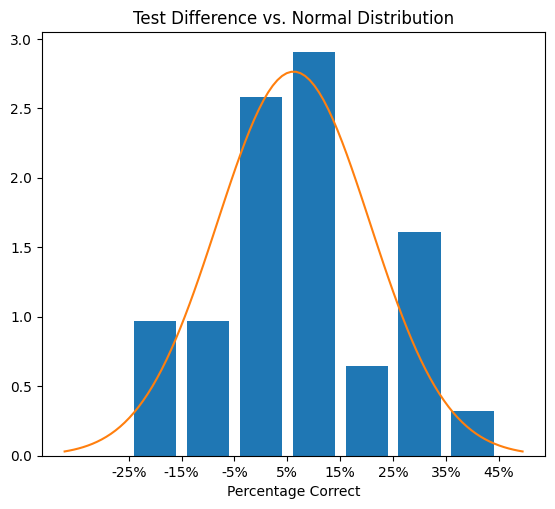

In [98]:
#Check for normality by doing a hist
#Set up some attributes that we'll use
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]

#Make the figure and format it
fig, plot = plt.subplots(1, 1)
fig.set_size_inches(6.5, 5.5)

#Plot the histogram
plot.hist(summaryDF['test_diff'], bins=diffBins, rwidth=0.8, density=True)

#Formatting
plot.set_xlabel("Percentage Correct")
plot.set_title('Test Difference vs. Normal Distribution')
plot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Plot the actual normal distribution
mean = summaryDF['test_diff'].mean()
std = summaryDF['test_diff'].std()
normPoints = np.linspace(mean - (3 * std), mean + (3 * std), 100)
plot.plot(normPoints, stats.norm.pdf(normPoints, mean, std))

#Show it
fig.show()

In [103]:
#Also do Kolmogorov-Smirnov test
fit = stats.norm.fit(summaryDF['test_diff'])

tmp, p = stats.kstest(summaryDF['test_diff'], 'norm', fit)
print(p)

0.22813663240187154


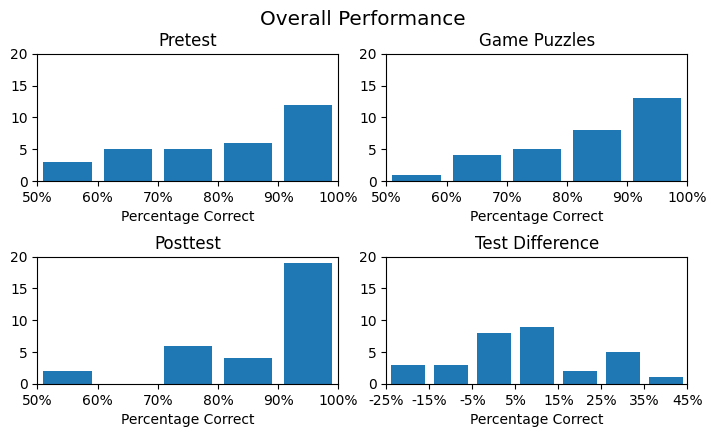

In [14]:
#Do the overall plots
#Set up some attributes that we'll use
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]
xlim = [0.5, 1]
ylim = [0, 20]

#Make the overall figure and do some formatting
fig, ((prePlot, gamePlot), (postPlot, diffPlot)) = plt.subplots(2, 2)
fig.set_size_inches(6.5, 5.5)
fig.tight_layout(w_pad = 0, h_pad = 6)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.3)
fig.suptitle('Overall Performance', fontsize='x-large')

#Make the actual plots
prePlot.hist(summaryDF['pre_total'], bins=bins, rwidth=0.8)
gamePlot.hist(summaryDF['proportion_passed'], bins=bins, rwidth=0.8)
postPlot.hist(summaryDF['post_total'], bins=bins, rwidth=0.8)
diffPlot.hist(summaryDF['test_diff'], bins=diffBins, rwidth=0.8)

#Do formatting on the plots
prePlot.set_xlabel("Percentage Correct")
prePlot.set_xlim(xlim)
prePlot.set_ylim(ylim)
prePlot.set_title('Pretest')
prePlot.set_xticks(bins, getLabelsForTicks(bins))

gamePlot.set_xlabel("Percentage Correct")
gamePlot.set_xlim(xlim)
gamePlot.set_ylim(ylim)
gamePlot.set_title('Game Puzzles')
gamePlot.set_xticks(bins, getLabelsForTicks(bins))

postPlot.set_xlabel("Percentage Correct")
postPlot.set_xlim(xlim)
postPlot.set_ylim(ylim)
postPlot.set_title('Posttest')
postPlot.set_xticks(bins, getLabelsForTicks(bins))

diffPlot.set_xlabel("Percentage Correct")
diffPlot.set_xlim([-0.25, 0.45])
diffPlot.set_ylim(ylim)
diffPlot.set_title('Test Difference')
diffPlot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Show it
fig.show()

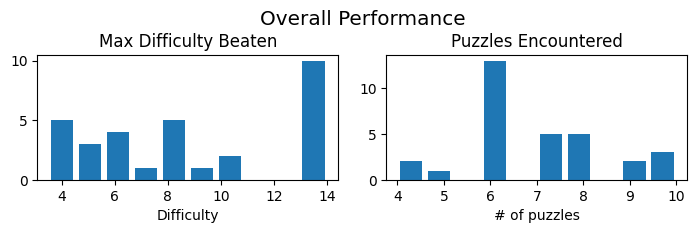

In [15]:
#Do the overall plots
#Make the overall figure and do some formatting
fig, (diffPlot, puzzPlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 2.5)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.subplots_adjust(left=0, right=1, top=0.8, bottom=0.3)
fig.suptitle('Overall Performance', fontsize='x-large')

#Make the actual plots
diffPlot.hist(summaryDF['max_dif_beaten'], rwidth=0.8)
puzzPlot.hist(summaryDF['puzzles_encountered'], rwidth=0.8)

#Do formatting on the plots
diffPlot.set_xlabel("Difficulty")
diffPlot.set_title('Max Difficulty Beaten')

puzzPlot.set_xlabel("# of puzzles")
puzzPlot.set_title('Puzzles Encountered')

#Show it
fig.show()

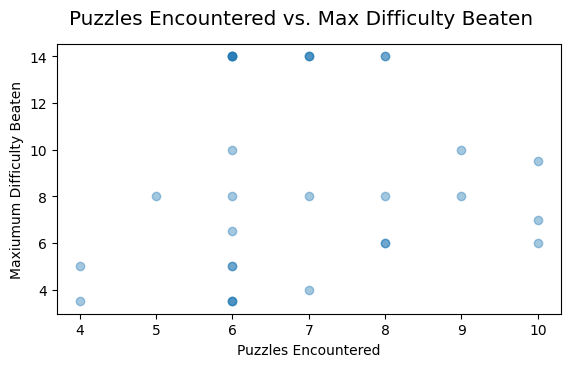

In [16]:
#Scatterplot of max diff vs puzzles
fig, (scatterPlot) = plt.subplots(1, 1)

#Figure formatting
fig.set_size_inches(6.5, 3.5)
fig.suptitle('Puzzles Encountered vs. Max Difficulty Beaten', fontsize='x-large')

#Actually do the plotting
scatterPlot.scatter(summaryDF['puzzles_encountered'], summaryDF['max_dif_beaten'], alpha=0.4)

#Plot formatting
scatterPlot.set_ylabel('Maxiumum Difficulty Beaten')
scatterPlot.set_xlabel('Puzzles Encountered')

#Show it
fig.show()

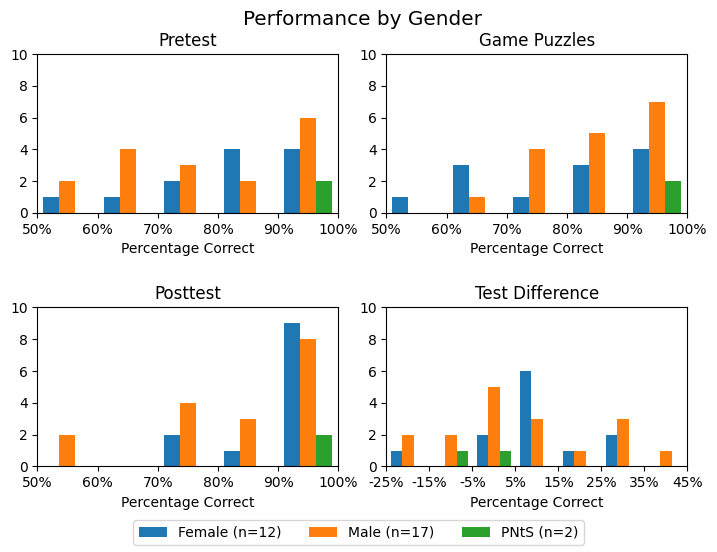

In [17]:
#Do the gender plots
#Set up some attributes that we'll use
catKey = 'gender'
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]
xlim = [0.5, 1]
ylim = [0, 10]

#Make the overall figure and do some formatting
fig, ((prePlot, gamePlot), (postPlot, diffPlot)) = plt.subplots(2, 2)
fig.set_size_inches(6.5, 5.5)
fig.tight_layout(w_pad = 0, h_pad = 6)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)
fig.suptitle('Performance by Gender', fontsize='x-large')

#Get a list of everything we want to plot
preList = []
gameList = []
postList = []
diffList = []
for key in frameDict[catKey].keys():
  preList.append(frameDict[catKey][key].pre_total)
for key in frameDict[catKey].keys():
  gameList.append(frameDict[catKey][key].proportion_passed)
for key in frameDict[catKey].keys():
  postList.append(frameDict[catKey][key].post_total)
for key in frameDict[catKey].keys():
  diffList.append(frameDict[catKey][key].test_diff)

#Make the actual plots
prePlot.hist(preList, bins=bins)
gamePlot.hist(gameList, bins=bins)
postPlot.hist(postList, bins=bins)
diffPlot.hist(diffList, bins=diffBins)

#Do formatting on the plots
prePlot.set_xlabel("Percentage Correct")
prePlot.set_xlim(xlim)
prePlot.set_ylim(ylim)
prePlot.set_title('Pretest')
prePlot.set_xticks(bins, getLabelsForTicks(bins))

gamePlot.set_xlabel("Percentage Correct")
gamePlot.set_xlim(xlim)
gamePlot.set_ylim(ylim)
gamePlot.set_title('Game Puzzles')
gamePlot.set_xticks(bins, getLabelsForTicks(bins))

postPlot.set_xlabel("Percentage Correct")
postPlot.set_xlim(xlim)
postPlot.set_ylim(ylim)
postPlot.set_title('Posttest')
postPlot.set_xticks(bins, getLabelsForTicks(bins))

diffPlot.set_xlabel("Percentage Correct")
diffPlot.set_xlim([-0.25, 0.45])
diffPlot.set_ylim(ylim)
diffPlot.set_title('Test Difference')
diffPlot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Make the legend
#fig.legend(frameDict[catKey].keys(), loc='lower center', ncol=3, )
fig.legend(['Female (n=12)', 'Male (n=17)', 'PNtS (n=2)'], loc='lower center', ncol=3, )

#Show it
fig.show()

In [18]:
import scipy.stats as stats

#Gender T-Tests
print('Male vs. Female Improvement Comparison')
print(stats.ttest_ind(frameDict['gender']['M'].test_diff, frameDict['gender']['F'].test_diff, equal_var=False))
print('Male avg = {:.2f}, std = {:.2f}'.format(frameDict['gender']['M'].test_diff.mean(), frameDict['gender']['M'].test_diff.std()))
print('Female avg = {:.2f}, std = {:.2f}'.format(frameDict['gender']['F'].test_diff.mean(), frameDict['gender']['F'].test_diff.std()))
print('PNtS avg = {:.2f}, std = {:.2f}'.format(frameDict['gender']['P'].test_diff.mean(), frameDict['gender']['P'].test_diff.std()))

Male vs. Female Improvement Comparison
TtestResult(statistic=np.float64(-0.4695034816213122), pvalue=np.float64(0.6424864643692867), df=np.float64(26.94928657208844))
Male avg = 0.06, std = 0.17
Female avg = 0.08, std = 0.11
PNtS avg = -0.04, std = 0.06


In [19]:
#Gender ANOVA tests
print('Gender ANOVA Results')
print(stats.f_oneway(frameDict['gender']['M'].test_diff, frameDict['gender']['F'].test_diff, frameDict['gender']['P'].test_diff))

Gender ANOVA Results
F_onewayResult(statistic=np.float64(0.6356548111386824), pvalue=np.float64(0.5370593587693331))


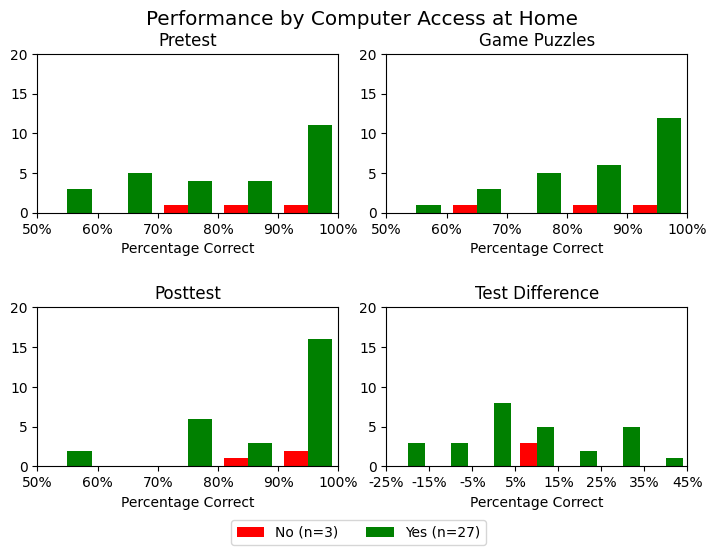

In [20]:
#Do the computer access plots
#Set up some attributes that we'll use
catKey = 'computer_access'
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]
xlim = [0.5, 1]
ylim = [0, 20]

#Make the overall figure and do some formatting
fig, ((prePlot, gamePlot), (postPlot, diffPlot)) = plt.subplots(2, 2)
fig.set_size_inches(6.5, 5.5)
fig.tight_layout(w_pad = 0, h_pad = 6)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)
fig.suptitle('Performance by Computer Access at Home', fontsize='x-large')

#Get a list of everything we want to plot
preList = []
gameList = []
postList = []
diffList = []
for key in frameDict[catKey].keys():
  preList.append(frameDict[catKey][key].pre_total)
for key in frameDict[catKey].keys():
  gameList.append(frameDict[catKey][key].proportion_passed)
for key in frameDict[catKey].keys():
  postList.append(frameDict[catKey][key].post_total)
for key in frameDict[catKey].keys():
  diffList.append(frameDict[catKey][key].test_diff)

#Make the actual plots
prePlot.hist(preList, bins=bins, color=['red', 'green'])
gamePlot.hist(gameList, bins=bins, color=['red', 'green'])
postPlot.hist(postList, bins=bins, color=['red', 'green'])
diffPlot.hist(diffList, bins=diffBins, color=['red', 'green'])

#Do formatting on the plots
prePlot.set_xlabel("Percentage Correct")
prePlot.set_xlim(xlim)
prePlot.set_ylim(ylim)
prePlot.set_title('Pretest')
prePlot.set_xticks(bins, getLabelsForTicks(bins))

gamePlot.set_xlabel("Percentage Correct")
gamePlot.set_xlim(xlim)
gamePlot.set_ylim(ylim)
gamePlot.set_title('Game Puzzles')
gamePlot.set_xticks(bins, getLabelsForTicks(bins))

postPlot.set_xlabel("Percentage Correct")
postPlot.set_xlim(xlim)
postPlot.set_ylim(ylim)
postPlot.set_title('Posttest')
postPlot.set_xticks(bins, getLabelsForTicks(bins))

diffPlot.set_xlabel("Percentage Correct")
diffPlot.set_xlim([-0.25, 0.45])
diffPlot.set_ylim(ylim)
diffPlot.set_title('Test Difference')
diffPlot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Make the legend
#fig.legend(frameDict[catKey].keys(), loc='lower center', ncol=3, )
fig.legend(['No (n=3)', 'Yes (n=27)'], loc='lower center', ncol=3, )

#Show it
fig.show()

In [21]:
#Computer access T-Tests
print('No access or yes access Improvement Comparison')
print(stats.ttest_ind(frameDict['computer_access']['0'].test_diff, frameDict['computer_access']['1'].test_diff, equal_var=False))
print('No avg = {:.2f}, std = {:.2f}'.format(frameDict['computer_access']['0'].test_diff.mean(), frameDict['computer_access']['0'].test_diff.std()))
print('Yes avg = {:.2f}, std = {:.2f}'.format(frameDict['computer_access']['1'].test_diff.mean(), frameDict['computer_access']['1'].test_diff.std()))

No access or yes access Improvement Comparison
TtestResult(statistic=np.float64(0.8292184909811912), pvalue=np.float64(0.414529182219073), df=np.float64(26.0))
No avg = 0.08, std = 0.00
Yes avg = 0.06, std = 0.15


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


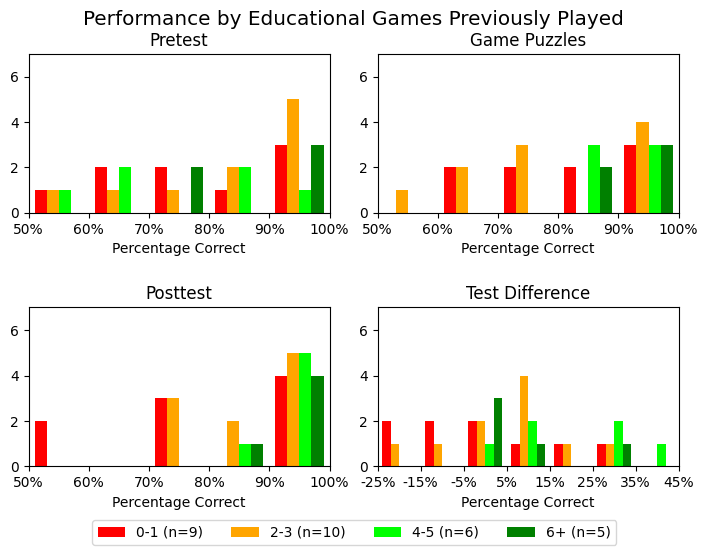

In [22]:
#Do the educational games played plots
#Set up some attributes that we'll use
catKey = 'game_count'
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]
xlim = [0.5, 1]
ylim = [0, 7]

#Make the overall figure and do some formatting
fig, ((prePlot, gamePlot), (postPlot, diffPlot)) = plt.subplots(2, 2)
fig.set_size_inches(6.5, 5.5)
fig.tight_layout(w_pad = 0, h_pad = 6)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)
fig.suptitle('Performance by Educational Games Previously Played', fontsize='x-large')

#Get a list of everything we want to plot
preList = []
gameList = []
postList = []
diffList = []
for key in frameDict[catKey].keys():
  preList.append(frameDict[catKey][key].pre_total)
for key in frameDict[catKey].keys():
  gameList.append(frameDict[catKey][key].proportion_passed)
for key in frameDict[catKey].keys():
  postList.append(frameDict[catKey][key].post_total)
for key in frameDict[catKey].keys():
  diffList.append(frameDict[catKey][key].test_diff)

#Make the actual plots
prePlot.hist(preList, bins=bins, color=['red', 'orange', 'lime', 'green'])
gamePlot.hist(gameList, bins=bins, color=['red', 'orange', 'lime', 'green'])
postPlot.hist(postList, bins=bins, color=['red', 'orange', 'lime', 'green'])
diffPlot.hist(diffList, bins=diffBins, color=['red', 'orange', 'lime', 'green'])

#Do formatting on the plots
prePlot.set_xlabel("Percentage Correct")
prePlot.set_xlim(xlim)
prePlot.set_ylim(ylim)
prePlot.set_title('Pretest')
prePlot.set_xticks(bins, getLabelsForTicks(bins))

gamePlot.set_xlabel("Percentage Correct")
gamePlot.set_xlim(xlim)
gamePlot.set_ylim(ylim)
gamePlot.set_title('Game Puzzles')
gamePlot.set_xticks(bins, getLabelsForTicks(bins))

postPlot.set_xlabel("Percentage Correct")
postPlot.set_xlim(xlim)
postPlot.set_ylim(ylim)
postPlot.set_title('Posttest')
postPlot.set_xticks(bins, getLabelsForTicks(bins))

diffPlot.set_xlabel("Percentage Correct")
diffPlot.set_xlim([-0.25, 0.45])
diffPlot.set_ylim(ylim)
diffPlot.set_title('Test Difference')
diffPlot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Make the legend
#fig.legend(frameDict[catKey].keys(), loc='lower center', ncol=3, )
fig.legend(['0-1 (n=9)', '2-3 (n=10)', '4-5 (n=6)', '6+ (n=5)'], loc='lower center', ncol=4, )

#Show it
fig.show()

In [23]:
#Ed games T-Tests
#Need to combine some groups, first is the first 2, second is the second 2
groupA = pd.concat([frameDict['game_count']['0-1'], frameDict['game_count']['2-3']])
groupB = pd.concat([frameDict['game_count']['4-5'], frameDict['game_count']['6+']])

#Do the actual tests
print('High or low game count Improvement Comparison')
print(stats.ttest_ind(groupA.test_diff, groupB.test_diff, equal_var=False))
print('<=3 avg = {:.2f}, std = {:.2f}'.format(groupA.test_diff.mean(), groupA.test_diff.std()))
print('>=4 avg = {:.2f}, std = {:.2f}'.format(groupB.test_diff.mean(), groupB.test_diff.std()))

High or low game count Improvement Comparison
TtestResult(statistic=np.float64(-2.011380784007215), pvalue=np.float64(0.05750793925356181), df=np.float64(20.667029489852126))
<=3 avg = 0.02, std = 0.14
>=4 avg = 0.13, std = 0.14


In [24]:
#Ed game ANOVA test
print('Games Previously Played ANOVA Results')
print(stats.f_oneway(frameDict['game_count']['0-1'].test_diff, frameDict['game_count']['2-3'].test_diff, frameDict['game_count']['4-5'].test_diff, frameDict['game_count']['6+'].test_diff))

#Print means and stds
print('0-1 avg = {:.2f}, std = {:.2f}'.format(frameDict['game_count']['0-1'].test_diff.mean(), frameDict['game_count']['0-1'].test_diff.std()))
print('2-3 avg = {:.2f}, std = {:.2f}'.format(frameDict['game_count']['2-3'].test_diff.mean(), frameDict['game_count']['2-3'].test_diff.std()))
print('4-5 avg = {:.2f}, std = {:.2f}'.format(frameDict['game_count']['4-5'].test_diff.mean(), frameDict['game_count']['4-5'].test_diff.std()))
print('6+ avg = {:.2f}, std = {:.2f}'.format(frameDict['game_count']['6+'].test_diff.mean(), frameDict['game_count']['6+'].test_diff.std()))

Games Previously Played ANOVA Results
F_onewayResult(statistic=np.float64(2.3150033944331287), pvalue=np.float64(0.09920962703717753))
0-1 avg = -0.01, std = 0.16
2-3 avg = 0.05, std = 0.12
4-5 avg = 0.18, std = 0.15
6+ avg = 0.07, std = 0.11


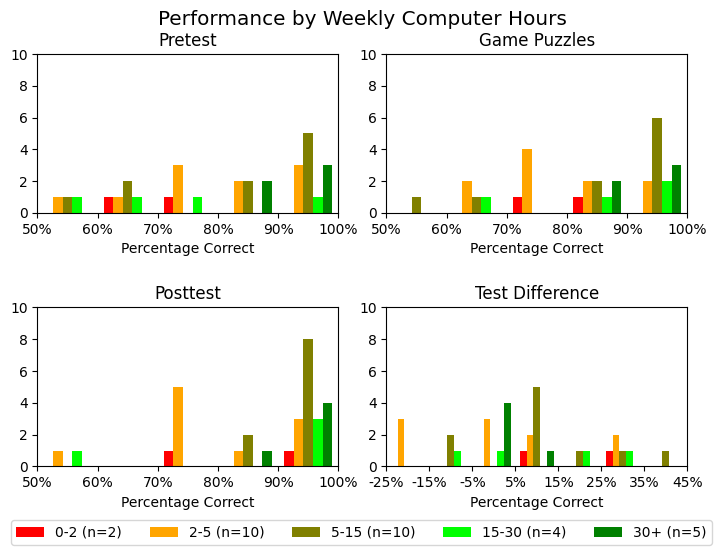

In [25]:
#Do the computer hours plots
#Set up some attributes that we'll use
catKey = 'overall_hours'
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]
xlim = [0.5, 1]
ylim = [0, 10]

#Make the overall figure and do some formatting
fig, ((prePlot, gamePlot), (postPlot, diffPlot)) = plt.subplots(2, 2)
fig.set_size_inches(6.5, 5.5)
fig.tight_layout(w_pad = 0, h_pad = 6)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)
fig.suptitle('Performance by Weekly Computer Hours', fontsize='x-large')

#Get a list of everything we want to plot
preList = []
gameList = []
postList = []
diffList = []
for key in frameDict[catKey].keys():
  preList.append(frameDict[catKey][key].pre_total)
for key in frameDict[catKey].keys():
  gameList.append(frameDict[catKey][key].proportion_passed)
for key in frameDict[catKey].keys():
  postList.append(frameDict[catKey][key].post_total)
for key in frameDict[catKey].keys():
  diffList.append(frameDict[catKey][key].test_diff)

#Make the actual plots
prePlot.hist(preList, bins=bins, color=['red', 'orange', 'olive', 'lime', 'green'])
gamePlot.hist(gameList, bins=bins, color=['red', 'orange', 'olive', 'lime', 'green'])
postPlot.hist(postList, bins=bins, color=['red', 'orange', 'olive', 'lime', 'green'])
diffPlot.hist(diffList, bins=diffBins, color=['red', 'orange', 'olive', 'lime', 'green'])

#Do formatting on the plots
prePlot.set_xlabel("Percentage Correct")
prePlot.set_xlim(xlim)
prePlot.set_ylim(ylim)
prePlot.set_title('Pretest')
prePlot.set_xticks(bins, getLabelsForTicks(bins))

gamePlot.set_xlabel("Percentage Correct")
gamePlot.set_xlim(xlim)
gamePlot.set_ylim(ylim)
gamePlot.set_title('Game Puzzles')
gamePlot.set_xticks(bins, getLabelsForTicks(bins))

postPlot.set_xlabel("Percentage Correct")
postPlot.set_xlim(xlim)
postPlot.set_ylim(ylim)
postPlot.set_title('Posttest')
postPlot.set_xticks(bins, getLabelsForTicks(bins))

diffPlot.set_xlabel("Percentage Correct")
diffPlot.set_xlim([-0.25, 0.45])
diffPlot.set_ylim(ylim)
diffPlot.set_title('Test Difference')
diffPlot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Make the legend
#fig.legend(frameDict[catKey].keys(), loc='lower center', ncol=3, )
fig.legend(['0-2 (n=2)', '2-5 (n=10)', '5-15 (n=10)', '15-30 (n=4)', '30+ (n=5)'], loc='lower center', ncol=5, )

#Show it
fig.show()

In [26]:
#Computer hours T-Tests
#Need to combine some groups, first is the first 2, second is the second 3
groupA = pd.concat([frameDict['overall_hours']['0-2'], frameDict['overall_hours']['2-5']])
groupB = pd.concat([frameDict['overall_hours']['5-15'], frameDict['overall_hours']['15-30'], frameDict['overall_hours']['30+']])

#Do the actual tests
print('High or low computer hours Improvement Comparison')
print(stats.ttest_ind(groupA.test_diff, groupB.test_diff, equal_var=False))
print('<5 avg = {:.2f}, std = {:.2f}'.format(groupA.test_diff.mean(), groupA.test_diff.std()))
print('>5 avg = {:.2f}, std = {:.2f}'.format(groupB.test_diff.mean(), groupB.test_diff.std()))

High or low computer hours Improvement Comparison
TtestResult(statistic=np.float64(-0.7775444028119155), pvalue=np.float64(0.44639549805678), df=np.float64(19.03297098646552))
<5 avg = 0.03, std = 0.17
>5 avg = 0.08, std = 0.13


In [27]:
#Computer hours ANOVA test
print('Computer Hours ANOVA Results')
print(stats.f_oneway(frameDict['overall_hours']['0-2'].test_diff, frameDict['overall_hours']['2-5'].test_diff, frameDict['overall_hours']['5-15'].test_diff, frameDict['overall_hours']['15-30'].test_diff, frameDict['overall_hours']['30+'].test_diff))

#Get means and sds
print('0-2 avg = {:.2f}, std = {:.2f}'.format(frameDict['overall_hours']['0-2'].test_diff.mean(), frameDict['overall_hours']['0-2'].test_diff.std()))
print('2-5 avg = {:.2f}, std = {:.2f}'.format(frameDict['overall_hours']['2-5'].test_diff.mean(), frameDict['overall_hours']['2-5'].test_diff.std()))
print('5-15 avg = {:.2f}, std = {:.2f}'.format(frameDict['overall_hours']['5-15'].test_diff.mean(), frameDict['overall_hours']['5-15'].test_diff.std()))
print('15-30 avg = {:.2f}, std = {:.2f}'.format(frameDict['overall_hours']['15-30'].test_diff.mean(), frameDict['overall_hours']['15-30'].test_diff.std()))
print('30+ avg = {:.2f}, std = {:.2f}'.format(frameDict['overall_hours']['30+'].test_diff.mean(), frameDict['overall_hours']['30+'].test_diff.std()))

Computer Hours ANOVA Results
F_onewayResult(statistic=np.float64(1.0138900406335518), pvalue=np.float64(0.4184273397629612))
0-2 avg = 0.17, std = 0.12
2-5 avg = 0.01, std = 0.17
5-15 avg = 0.11, std = 0.15
15-30 avg = 0.08, std = 0.15
30+ avg = 0.02, std = 0.04


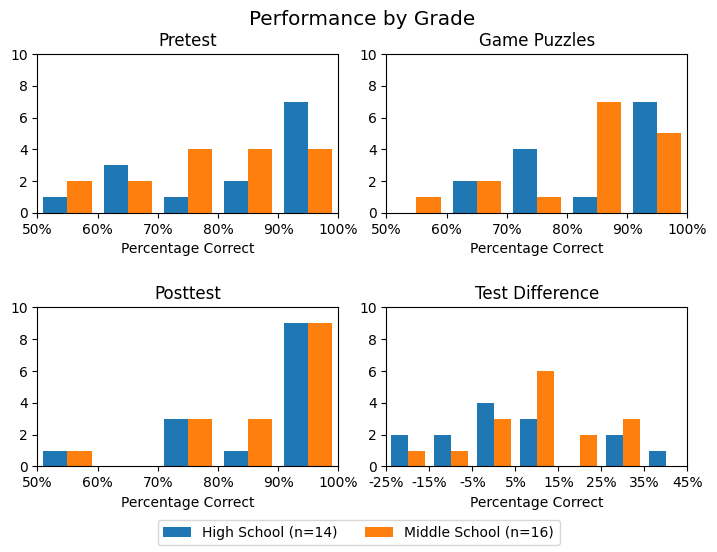

In [28]:
#Do the grade plots
#Set up some attributes that we'll use
catKey = 'grade'
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]
xlim = [0.5, 1]
ylim = [0, 10]

#Make the overall figure and do some formatting
fig, ((prePlot, gamePlot), (postPlot, diffPlot)) = plt.subplots(2, 2)
fig.set_size_inches(6.5, 5.5)
fig.tight_layout(w_pad = 0, h_pad = 6)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)
fig.suptitle('Performance by Grade', fontsize='x-large')

#Get a list of everything we want to plot
preList = []
gameList = []
postList = []
diffList = []
for key in frameDict[catKey].keys():
  if key != '-':
    preList.append(frameDict[catKey][key].pre_total)
for key in frameDict[catKey].keys():
  if key != '-':
    gameList.append(frameDict[catKey][key].proportion_passed)
for key in frameDict[catKey].keys():
  if key != '-':
    postList.append(frameDict[catKey][key].post_total)
for key in frameDict[catKey].keys():
  if key != '-':
    diffList.append(frameDict[catKey][key].test_diff)

#Make the actual plots
prePlot.hist(preList, bins=bins)
gamePlot.hist(gameList, bins=bins)
postPlot.hist(postList, bins=bins)
diffPlot.hist(diffList, bins=diffBins)

#Do formatting on the plots
prePlot.set_xlabel("Percentage Correct")
prePlot.set_xlim(xlim)
prePlot.set_ylim(ylim)
prePlot.set_title('Pretest')
prePlot.set_xticks(bins, getLabelsForTicks(bins))

gamePlot.set_xlabel("Percentage Correct")
gamePlot.set_xlim(xlim)
gamePlot.set_ylim(ylim)
gamePlot.set_title('Game Puzzles')
gamePlot.set_xticks(bins, getLabelsForTicks(bins))

postPlot.set_xlabel("Percentage Correct")
postPlot.set_xlim(xlim)
postPlot.set_ylim(ylim)
postPlot.set_title('Posttest')
postPlot.set_xticks(bins, getLabelsForTicks(bins))

diffPlot.set_xlabel("Percentage Correct")
diffPlot.set_xlim([-0.25, 0.45])
diffPlot.set_ylim(ylim)
diffPlot.set_title('Test Difference')
diffPlot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Make the legend
#fig.legend(frameDict[catKey].keys(), loc='lower center', ncol=3, )
fig.legend(['High School (n=14)', 'Middle School (n=16)'], loc='lower center', ncol=2, )

#Show it
fig.show()

In [29]:
#Computer hours T-Tests
#Need to combine some groups, first is the first, second is the second
groupA = pd.concat([frameDict['grade']['high']])
groupB = pd.concat([frameDict['grade']['middle']])

#Do the actual tests
print('Middle and high school Improvement Comparison')
print(stats.ttest_ind(groupA.test_diff, groupB.test_diff, equal_var=False))
print('High school avg = {:.2f}, std = {:.2f}'.format(groupA.test_diff.mean(), groupA.test_diff.std()))
print('Middle school avg = {:.2f}, std = {:.2f}'.format(groupB.test_diff.mean(), groupB.test_diff.std()))

Middle and high school Improvement Comparison
TtestResult(statistic=np.float64(-0.75297954364406), pvalue=np.float64(0.45933926268944225), df=np.float64(22.296985084663756))
High school avg = 0.04, std = 0.18
Middle school avg = 0.08, std = 0.12


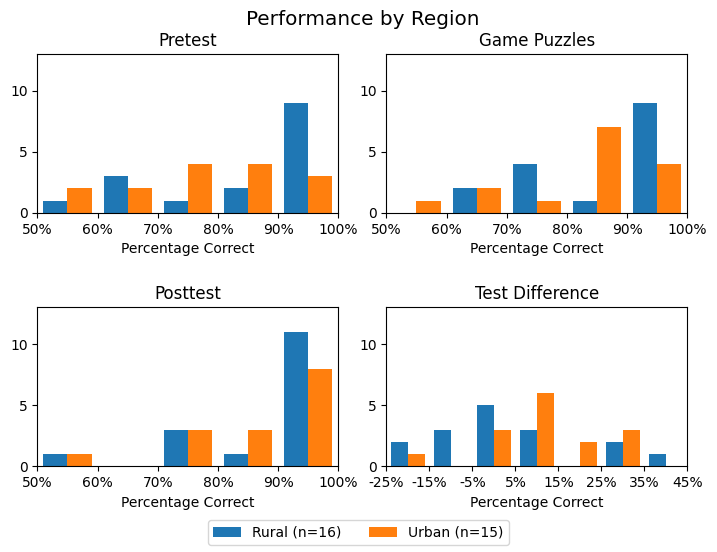

In [30]:
#Do the region plots
#Set up some attributes that we'll use
catKey = 'region'
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
diffBins = [-0.25, -0.15, -0.05, 0.05, 0.15, 0.25, 0.35, 0.45]
xlim = [0.5, 1]
ylim = [0, 13]

#Make the overall figure and do some formatting
fig, ((prePlot, gamePlot), (postPlot, diffPlot)) = plt.subplots(2, 2)
fig.set_size_inches(6.5, 5.5)
fig.tight_layout(w_pad = 0, h_pad = 6)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)
fig.suptitle('Performance by Region', fontsize='x-large')

#Get a list of everything we want to plot
preList = []
gameList = []
postList = []
diffList = []
for key in frameDict[catKey].keys():
  if key != '-':
    preList.append(frameDict[catKey][key].pre_total)
for key in frameDict[catKey].keys():
  if key != '-':
    gameList.append(frameDict[catKey][key].proportion_passed)
for key in frameDict[catKey].keys():
  if key != '-':
    postList.append(frameDict[catKey][key].post_total)
for key in frameDict[catKey].keys():
  if key != '-':
    diffList.append(frameDict[catKey][key].test_diff)

#Make the actual plots
prePlot.hist(preList, bins=bins)
gamePlot.hist(gameList, bins=bins)
postPlot.hist(postList, bins=bins)
diffPlot.hist(diffList, bins=diffBins)

#Do formatting on the plots
prePlot.set_xlabel("Percentage Correct")
prePlot.set_xlim(xlim)
prePlot.set_ylim(ylim)
prePlot.set_title('Pretest')
prePlot.set_xticks(bins, getLabelsForTicks(bins))

gamePlot.set_xlabel("Percentage Correct")
gamePlot.set_xlim(xlim)
gamePlot.set_ylim(ylim)
gamePlot.set_title('Game Puzzles')
gamePlot.set_xticks(bins, getLabelsForTicks(bins))

postPlot.set_xlabel("Percentage Correct")
postPlot.set_xlim(xlim)
postPlot.set_ylim(ylim)
postPlot.set_title('Posttest')
postPlot.set_xticks(bins, getLabelsForTicks(bins))

diffPlot.set_xlabel("Percentage Correct")
diffPlot.set_xlim([-0.25, 0.45])
diffPlot.set_ylim(ylim)
diffPlot.set_title('Test Difference')
diffPlot.set_xticks(diffBins, getLabelsForTicks(diffBins))

#Make the legend
#fig.legend(frameDict[catKey].keys(), loc='lower center', ncol=3, )
fig.legend(['Rural (n=16)', 'Urban (n=15)'], loc='lower center', ncol=2, )

#Show it
fig.show()

In [31]:
#Region T-Tests
#Need to combine some groups, first is the first, second is the second
groupA = pd.concat([frameDict['region']['urban']])
groupB = pd.concat([frameDict['region']['rural']])

#Do the actual tests
print('Region Improvement Comparison')
print(stats.ttest_ind(groupA.test_diff, groupB.test_diff, equal_var=False))
print('Urban avg = {:.2f}, std = {:.2f}'.format(groupA.test_diff.mean(), groupA.test_diff.std()))
print('Rural avg = {:.2f}, std = {:.2f}'.format(groupB.test_diff.mean(), groupB.test_diff.std()))

Region Improvement Comparison
TtestResult(statistic=np.float64(1.2441762216764523), pvalue=np.float64(0.22432055920894833), df=np.float64(26.51714599384191))
Urban avg = 0.09, std = 0.11
Rural avg = 0.03, std = 0.17


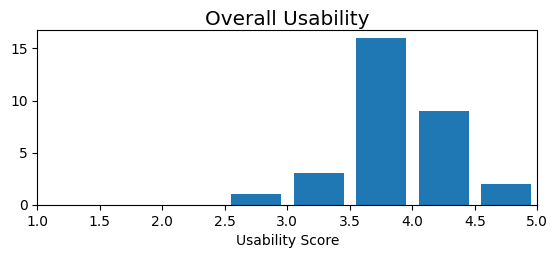

In [32]:
#Make histogram for overall sentiment scores
fig, plot = plt.subplots(1, 1)
fig.set_size_inches(5, 2.5)
fig.tight_layout(w_pad = 0, h_pad = 5)

plot.hist(summaryDF['usability_avg'], bins=[1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5], rwidth=0.8)
plot.set_xlabel('Usability Score')
plot.set_xbound(1, 5)
fig.suptitle('Overall Usability', fontsize='x-large')
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.2)
fig.show()

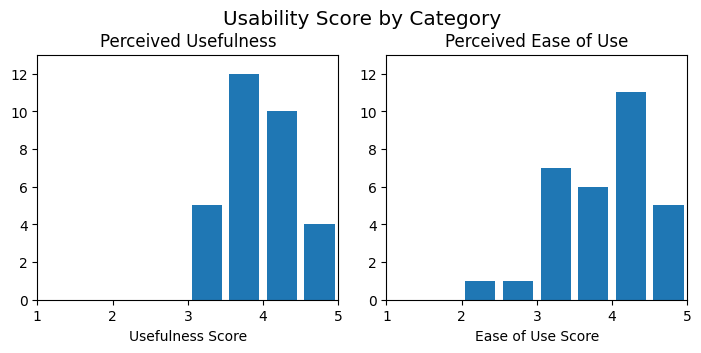

In [33]:
#Do the sentiment category histograms
bins = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]

#Make the overall figure and do some formatting
fig, (usePlot, easePlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 3.5)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.subplots_adjust(left=0, right=1, top=0.85, bottom=0.15)
fig.suptitle('Usability Score by Category', fontsize='x-large')

#Make the actual plots
usePlot.hist(summaryDF['use_avg'], bins=bins, rwidth=0.8)
usePlot.set_xlabel('Usefulness Score')
usePlot.set_xbound(1, 5)
usePlot.set_title('Perceived Usefulness')
usePlot.set_ybound(0, 13)

easePlot.hist(summaryDF['ease_avg'], bins=bins, rwidth=0.8)
easePlot.set_xlabel('Ease of Use Score')
easePlot.set_xbound(1, 5)
easePlot.set_title('Perceived Ease of Use')
easePlot.set_ybound(0, 13)

#Show it
fig.show()

# Sequence stuff

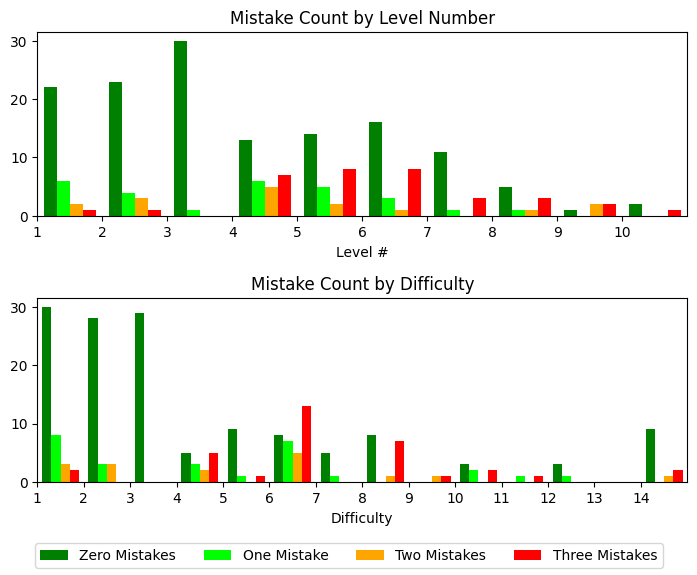

In [34]:
#Make histograms for how many mistakes players make by level and difficulty
#Start by splitting the data up
zeroMistakeDF = puzzleDF[puzzleDF['mistakes'] == 0]
oneMistakeDF = puzzleDF[puzzleDF['mistakes'] == 1]
twoMistakeDF = puzzleDF[puzzleDF['mistakes'] == 2]
threeMistakeDF = puzzleDF[puzzleDF['mistakes'] == 3]

#Define some parameters that we'll use
nrows = 2
ncols = 1

#Make the overall figure and do some formatting
fig, (levelPlot, diffPlot) = plt.subplots(nrows, ncols)
fig.set_size_inches(6.5, 6)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)

#Define what we're gonna plot as a tuple
levelHistData = (zeroMistakeDF.level, oneMistakeDF.level, twoMistakeDF.level, threeMistakeDF.level)
diffHistData = (zeroMistakeDF['diff'], oneMistakeDF['diff'], twoMistakeDF['diff'], threeMistakeDF['diff'])

#Make the actual plots
levelPlot.hist(levelHistData, bins=range(1, 12, 1), color=['green', 'lime', 'orange', 'red'])
diffPlot.hist(diffHistData, bins=range(1, 16, 1), color=['green', 'lime', 'orange', 'red'])

#Format the plots
levelPlot.set(xlabel='Level #')
diffPlot.set(xlabel='Difficulty')
levelPlot.set_title('Mistake Count by Level Number')
diffPlot.set_title('Mistake Count by Difficulty')
levelPlot.set_xticks(range(1, 11, 1))
diffPlot.set_xticks(range(1, 15, 1))
levelPlot.set_xlim([1, 11])
diffPlot.set_xlim([1, 15])

#Make the legend
fig.legend(['Zero Mistakes', 'One Mistake', 'Two Mistakes', 'Three Mistakes'], ncol=4, loc='lower center')

#Show it
fig.show()

In [35]:
#Prep for normalized bar graph of mistakes players made by level and difficulty
levelTotals = [0] * 10
diffTotals = [0] * 14

#Count occurences of each level
for i in range(1, 11):
  levelTotals[i-1] = len(puzzleDF[puzzleDF['level'] == i])

#Count occurences of each diff
for i in range(1, 15):
  diffTotals[i-1] = len(puzzleDF[(puzzleDF['diff'] >= i) & (puzzleDF['diff'] < i+1)])
print(levelTotals)
print(diffTotals)

levelMistakes = [None] * 4
diffMistakes = [None] * 4

#Count mistakes for each level
for i in range(4):
  mistakeArray = [0] * 10
  for j in range(1, 11):
    mistakeArray[j-1] = len(puzzleDF[(puzzleDF['level'] == j) & (puzzleDF['mistakes'] == i)])
  levelMistakes[i] = mistakeArray

#Count mistakes for each diff
for i in range(4):
  mistakeArray = [0] * 14
  for j in range(1, 15):
    mistakeArray[j-1] = len(puzzleDF[(puzzleDF['diff'] >= j) & (puzzleDF['diff'] < j+1) & (puzzleDF['mistakes'] == i)])
  diffMistakes[i] = mistakeArray

print(levelMistakes)
print(diffMistakes)

#Divide mistakes by totals
for i in range(10):
  for j in range(4):
    levelMistakes[j][i] /= levelTotals[i]

for i in range(14):
  for j in range(4):
    if diffTotals[i] != 0:
      diffMistakes[j][i] /= diffTotals[i]

print(levelMistakes)
print(diffMistakes)

[31, 31, 31, 31, 29, 28, 15, 10, 5, 3]
[43, 34, 29, 15, 11, 33, 6, 16, 2, 7, 2, 4, 0, 12]
[[22, 23, 30, 13, 14, 16, 11, 5, 1, 2], [6, 4, 1, 6, 5, 3, 1, 1, 0, 0], [2, 3, 0, 5, 2, 1, 0, 1, 2, 0], [1, 1, 0, 7, 8, 8, 3, 3, 2, 1]]
[[30, 28, 29, 5, 9, 8, 5, 8, 0, 3, 0, 3, 0, 9], [8, 3, 0, 3, 1, 7, 1, 0, 0, 2, 1, 1, 0, 0], [3, 3, 0, 2, 0, 5, 0, 1, 1, 0, 0, 0, 0, 1], [2, 0, 0, 5, 1, 13, 0, 7, 1, 2, 1, 0, 0, 2]]
[[0.7096774193548387, 0.7419354838709677, 0.967741935483871, 0.41935483870967744, 0.4827586206896552, 0.5714285714285714, 0.7333333333333333, 0.5, 0.2, 0.6666666666666666], [0.1935483870967742, 0.12903225806451613, 0.03225806451612903, 0.1935483870967742, 0.1724137931034483, 0.10714285714285714, 0.06666666666666667, 0.1, 0.0, 0.0], [0.06451612903225806, 0.0967741935483871, 0.0, 0.16129032258064516, 0.06896551724137931, 0.03571428571428571, 0.0, 0.1, 0.4, 0.0], [0.03225806451612903, 0.03225806451612903, 0.0, 0.22580645161290322, 0.27586206896551724, 0.2857142857142857, 0.2, 0.3, 0.4, 0.3

[[1.1, 2.1, 3.1, 4.1, 5.1, 6.1, 7.1, 8.1, 9.1, 10.1], [1.3, 2.3000000000000003, 3.3000000000000003, 4.3, 5.3, 6.3, 7.3, 8.299999999999999, 9.299999999999999, 10.299999999999999], [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], [1.7000000000000002, 2.7, 3.7, 4.699999999999999, 5.699999999999999, 6.699999999999999, 7.699999999999999, 8.7, 9.7, 10.7]]
[[1.1, 2.1, 3.1, 4.1, 5.1, 6.1, 7.1, 8.1, 9.1, 10.1, 11.1, 12.1, 13.1, 14.1], [1.3, 2.3000000000000003, 3.3000000000000003, 4.3, 5.3, 6.3, 7.3, 8.299999999999999, 9.299999999999999, 10.299999999999999, 11.299999999999999, 12.299999999999999, 13.299999999999999, 14.299999999999999], [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5], [1.7000000000000002, 2.7, 3.7, 4.699999999999999, 5.699999999999999, 6.699999999999999, 7.699999999999999, 8.7, 9.7, 10.7, 11.7, 12.7, 13.7, 14.7]]


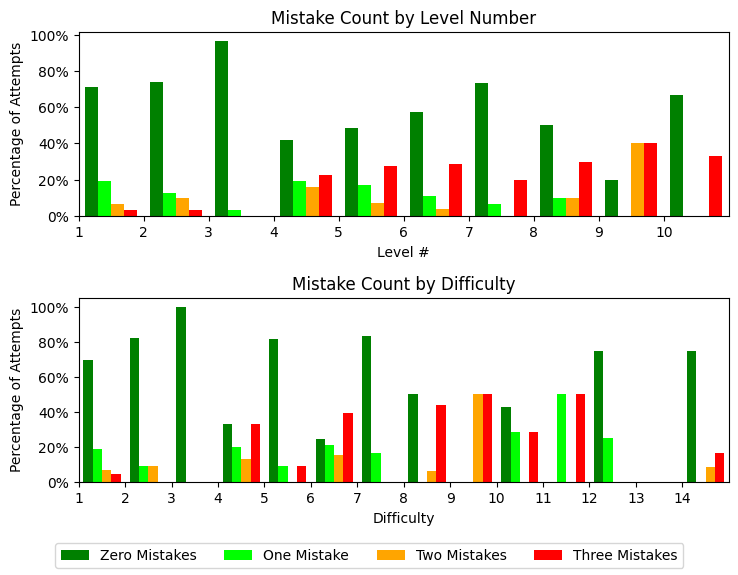

In [36]:
#Making the actual bar graph
#Define some parameters that we'll use
nrows = 2
ncols = 1

#Make the spots that each bar will appear at
levelPositions = [None] * 4
diffPositions = [None] * 4

for i in range(4):
  curPositions = [0] * 10
  for j in range(1, 11):
    curPositions[j-1] = j + 0.1 + (0.2 * i)
  levelPositions[i] = curPositions
print(levelPositions)

for i in range(4):
  curPositions = [0] * 14
  for j in range(1, 15):
    curPositions[j-1] = j + 0.1 + (0.2 * i)
  diffPositions[i] = curPositions
print(diffPositions)

#Make the overall figure and do some formatting
fig, (levelPlot, diffPlot) = plt.subplots(nrows, ncols)
fig.set_size_inches(6.5, 6)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)

#Make the actual plots
levelPlot.bar(levelPositions[0], levelMistakes[0], align='edge', color='green', width=0.2)
levelPlot.bar(levelPositions[1], levelMistakes[1], align='edge', color='lime', width=0.2)
levelPlot.bar(levelPositions[2], levelMistakes[2], align='edge', color='orange', width=0.2)
levelPlot.bar(levelPositions[3], levelMistakes[3], align='edge', color='red', width=0.2)

diffPlot.bar(diffPositions[0], diffMistakes[0], align='edge', color='green', width=0.2)
diffPlot.bar(diffPositions[1], diffMistakes[1], align='edge', color='lime', width=0.2)
diffPlot.bar(diffPositions[2], diffMistakes[2], align='edge', color='orange', width=0.2)
diffPlot.bar(diffPositions[3], diffMistakes[3], align='edge', color='red', width=0.2)

#Format the plots
levelPlot.set(xlabel='Level #')
diffPlot.set(xlabel='Difficulty')
levelPlot.set_ylabel("Percentage of Attempts")
diffPlot.set_ylabel("Percentage of Attempts")
levelPlot.set_title('Mistake Count by Level Number')
diffPlot.set_title('Mistake Count by Difficulty')
levelPlot.set_xticks(range(1, 11, 1))
diffPlot.set_xticks(range(1, 15, 1))
levelPlot.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0%', '20%', '40%', '60%', '80%', '100%'])
diffPlot.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0%', '20%', '40%', '60%', '80%', '100%'])
levelPlot.set_xlim([1, 11])
diffPlot.set_xlim([1, 15])

#Make the legend
fig.legend(['Zero Mistakes', 'One Mistake', 'Two Mistakes', 'Three Mistakes'], ncol=4, loc='lower center')

#Show it
fig.show()

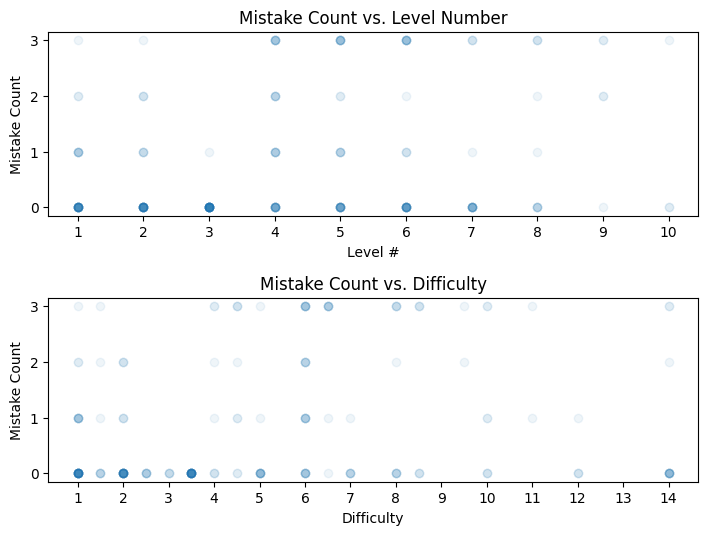

In [37]:
#Scatterplots comparing mistake count with level and difficulty
fig, (levelScatter, diffScatter) = plt.subplots(2, 1)
fig.set_size_inches(6.5, 6)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)

#Do the actual plotting
levelScatter.scatter(puzzleDF['level'], puzzleDF['mistakes'], alpha=0.07)
diffScatter.scatter(puzzleDF['diff'], puzzleDF['mistakes'], alpha=0.07)

#Format the plots
levelScatter.set(xlabel='Level #')
diffScatter.set(xlabel='Difficulty')
levelScatter.set_ylabel('Mistake Count')
diffScatter.set_ylabel('Mistake Count')
levelScatter.set_title('Mistake Count vs. Level Number')
diffScatter.set_title('Mistake Count vs. Difficulty')
levelScatter.set_xticks(range(1, 11, 1))
diffScatter.set_xticks(range(1, 15, 1))

#Show it
fig.show()

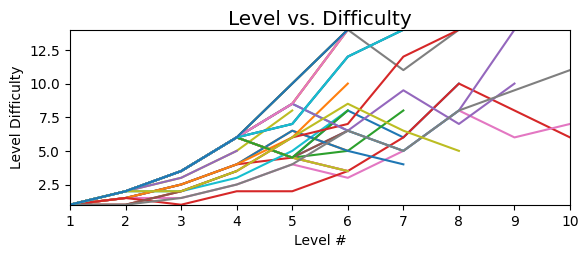

In [38]:
#Line plot of every student's progression, plotting difficulty against level #
#First, split the sequence data by ID
studentDFDict = {}
for id in idDF.id:
  studentDFDict[id] = puzzleDF[puzzleDF['id'] == id]

#Histogram of test and game metrics
fig, plot = plt.subplots(1, 1)
fig.set_size_inches(5, 2.5)
fig.tight_layout(w_pad = 0, h_pad = 5)

for key in studentDFDict.keys():
  plot.plot(studentDFDict[key]['level'], studentDFDict[key]['diff'])

plot.set_xlabel('Level #')
plot.set_ylabel('Level Difficulty')
plot.set_xbound(1, 10)
plot.set_ybound(1, 14)
fig.suptitle('Level vs. Difficulty', fontsize='x-large')
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.2)
fig.show()

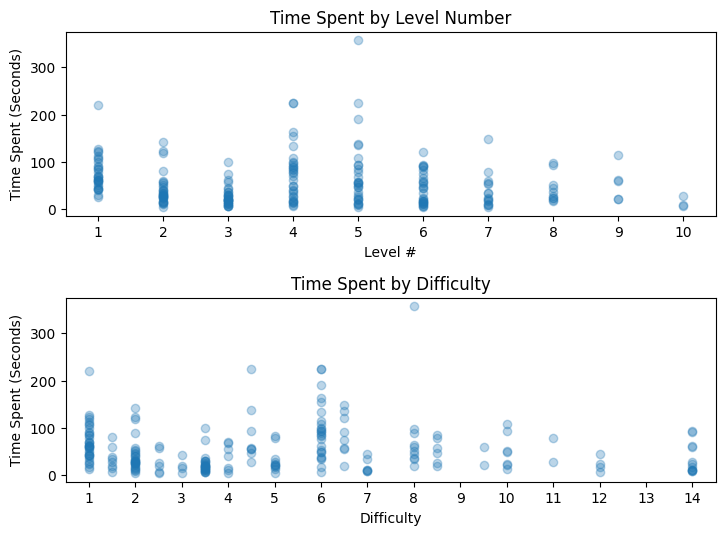

In [39]:
#Make line plots for time spent by level and difficulty
#Define some parameters that we'll use
nrows = 2
ncols = 1

#Make the overall figure and do some formatting
fig, (levelPlot, diffPlot) = plt.subplots(nrows, ncols)
fig.set_size_inches(6.5, 6)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.15)

#Do the actual plotting
#for key in studentDFDict.keys():
#  levelPlot.plot(studentDFDict[key]['level'], studentDFDict[key]['time'])
#for key in studentDFDict.keys():
#  diffPlot.plot(studentDFDict[key]['diff'], studentDFDict[key]['time'])
levelPlot.scatter(puzzleDF['level'], puzzleDF['time'], alpha=0.3)
diffPlot.scatter(puzzleDF['diff'], puzzleDF['time'], alpha=0.3)

#Format the plots
levelPlot.set(xlabel='Level #')
diffPlot.set(xlabel='Difficulty')
levelPlot.set_ylabel('Time Spent (Seconds)')
diffPlot.set_ylabel('Time Spent (Seconds)')
levelPlot.set_title('Time Spent by Level Number')
diffPlot.set_title('Time Spent by Difficulty')
levelPlot.set_xticks(range(1, 11, 1))
diffPlot.set_xticks(range(1, 15, 1))
levelPlot.set_xlim([0.5, 10.5])
diffPlot.set_xlim([0.5, 14.5])

#Show it
fig.show()

# Correlation & Plots

In [40]:
import matplotlib.pyplot as plt

In [41]:
#Correlation matrix for all numerical data
summaryDF.corr(numeric_only=True)

,id,max_dif_beaten,puzzles_beaten,puzzles_failed,puzzles_encountered,proportion_passed,pre_total,post_total,test_diff,sentiment,usability_avg,use_avg,ease_avg
id,1.000000,-0.059301,-0.182075,0.147075,-0.028749,-0.209174,0.141839,0.001266,-0.138243,0.175979,0.175979,0.251439,0.041979
max_dif_beaten,-0.059301,1.000000,0.676925,-0.538695,0.112720,0.636070,0.230352,0.361290,0.082174,0.510144,0.510144,0.282149,0.560120
puzzles_beaten,-0.182075,0.676925,1.000000,-0.060849,0.695546,0.242426,0.051479,0.164598,0.089955,0.248854,0.248854,0.220497,0.191913
puzzles_failed,0.147075,-0.538695,-0.060849,1.000000,0.674827,-0.965851,-0.086828,-0.223498,-0.105516,-0.311487,-0.311487,-0.107945,-0.405136
puzzles_encountered,-0.028749,0.112720,0.695546,0.674827,1.000000,-0.515998,-0.024439,-0.039182,-0.009445,-0.040225,-0.040225,0.085323,-0.149733
proportion_passed,-0.209174,0.636070,0.242426,-0.965851,-0.515998,1.000000,0.085304,0.222148,0.105861,0.366868,0.366868,0.135887,0.468580
pre_total,0.141839,0.230352,0.051479,-0.086828,-0.024439,0.085304,1.000000,0.413608,-0.629162,-0.085633,-0.085633,-0.158111,0.014666
post_total,0.001266,0.361290,0.164598,-0.223498,-0.039182,0.222148,0.413608,1.000000,0.447447,0.044121,0.044121,0.029795,0.043152
test_diff,-0.138243,0.082174,0.089955,-0.105516,-0.009445,0.105861,-0.629162,0.447447,1.000000,0.121782,0.121782,0.180744,0.022434
sentiment,0.175979,0.510144,0.248854,-0.311487,-0.040225,0.366868,-0.085633,0.044121,0.121782,1.000000,1.000000,0.824480,0.831613


In [42]:
import scipy.stats as stats

#Pearson correlations for relevant data
print('Sentiment vs. Encountered')
print(stats.pearsonr(summaryDF['sentiment'], summaryDF['puzzles_encountered']))

print('\nSentiment vs. Passed')
print(stats.pearsonr(summaryDF['sentiment'], summaryDF['proportion_passed']))

print('\nSentiment vs. Improvement')
print(stats.pearsonr(summaryDF['sentiment'], summaryDF['test_diff']))

print('\nImprovement vs. Encountered')
print(stats.pearsonr(summaryDF['test_diff'], summaryDF['puzzles_encountered']))

print('\nImprovement vs. Passed')
print(stats.pearsonr(summaryDF['test_diff'], summaryDF['proportion_passed']))

#Not related to hypotheses, but could still be handy
print('\nEncountered vs. Passed')
print(stats.pearsonr(summaryDF['puzzles_encountered'], summaryDF['proportion_passed']))

Sentiment vs. Encountered
PearsonRResult(statistic=np.float64(-0.0402245752241542), pvalue=np.float64(0.8298888059317178))

Sentiment vs. Passed
PearsonRResult(statistic=np.float64(0.3668682799449306), pvalue=np.float64(0.04234629341156896))

Sentiment vs. Improvement
PearsonRResult(statistic=np.float64(0.1217816798481356), pvalue=np.float64(0.5139989489049472))

Improvement vs. Encountered
PearsonRResult(statistic=np.float64(-0.0094448611887047), pvalue=np.float64(0.9597823074443267))

Improvement vs. Passed
PearsonRResult(statistic=np.float64(0.10586098076744889), pvalue=np.float64(0.5708607793391149))

Encountered vs. Passed
PearsonRResult(statistic=np.float64(-0.5159980707679702), pvalue=np.float64(0.0029652543607649))


<Figure size 640x480 with 0 Axes>

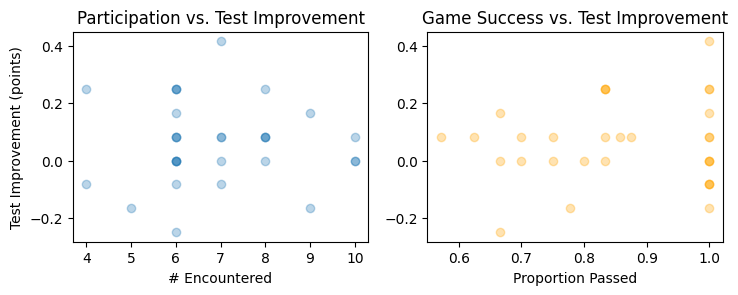

In [43]:
# H1 and H2 plots
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot, succPlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(summaryDF.puzzles_encountered, summaryDF.test_diff, alpha=0.3)
succPlot.scatter(summaryDF.proportion_passed, summaryDF.test_diff, c = 'orange', alpha=0.3)

#Formatting
partPlot.set_title('Participation vs. Test Improvement')
succPlot.set_title('Game Success vs. Test Improvement')
partPlot.set(xlabel='# Encountered')
partPlot.set(ylabel='Test Improvement (points)')
succPlot.set(xlabel='Proportion Passed')

#Show it
fig.show()

In [44]:
#H3 Stuff

<Figure size 640x480 with 0 Axes>

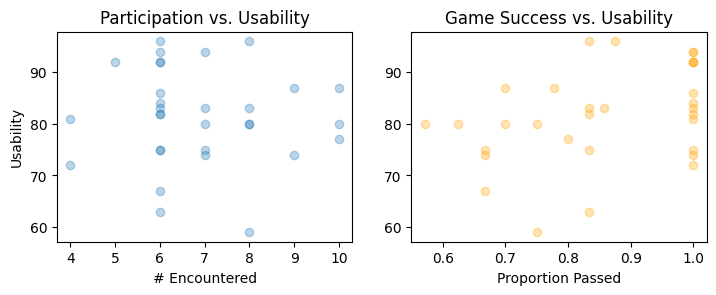

In [45]:
#H4 and H5 Stuff
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot, succPlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(summaryDF.puzzles_encountered, summaryDF.sentiment, alpha=0.3)
succPlot.scatter(summaryDF.proportion_passed, summaryDF.sentiment, c = 'orange', alpha=0.3)

#Formatting
partPlot.set_title('Participation vs. Usability')
succPlot.set_title('Game Success vs. Usability')
partPlot.set(xlabel='# Encountered')
partPlot.set(ylabel='Usability')
succPlot.set(xlabel='Proportion Passed')

#Show it
fig.show()

<Figure size 640x480 with 0 Axes>

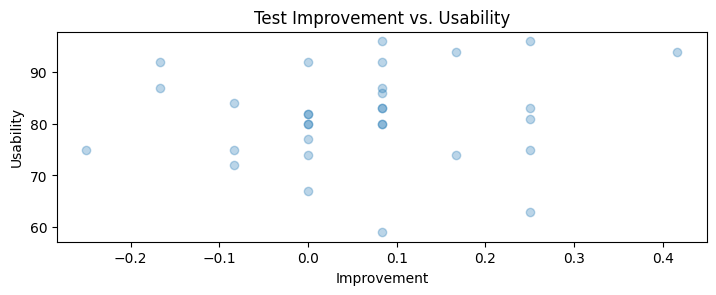

In [46]:
#H6 Stuff
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot) = plt.subplots(1, 1)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(summaryDF.test_diff, summaryDF.sentiment, alpha=0.3)

#Formatting
partPlot.set_title('Test Improvement vs. Usability')
partPlot.set(xlabel='Improvement')
partPlot.set(ylabel='Usability')

#Show it
fig.show()

# Correlation Above Median Pretest Score

In [47]:
import matplotlib.pyplot as plt

In [48]:
#Correlation matrix for all numerical data
median = summaryDF.pre_total.median() #We use median due to the skewed data
aboveDF = summaryDF[summaryDF['pre_total'] > median]
aboveDF.corr(numeric_only=True)

,id,max_dif_beaten,puzzles_beaten,puzzles_failed,puzzles_encountered,proportion_passed,pre_total,post_total,test_diff,sentiment,usability_avg,use_avg,ease_avg
id,1.000000,0.019870,-9.324826e-02,4.486353e-02,-4.971463e-02,-0.097823,-0.100464,3.114257e-01,0.373502,0.155264,0.155264,0.264966,-0.026385
max_dif_beaten,0.019870,1.000000,8.746175e-01,-5.836299e-01,3.330494e-01,0.631737,0.127199,1.753082e-01,0.125941,0.493737,0.493737,0.357554,0.422473
puzzles_beaten,-0.093248,0.874617,1.000000e+00,-3.485075e-01,6.416579e-01,0.439824,0.151911,8.832848e-17,-0.069702,0.402270,0.402270,0.380024,0.251595
puzzles_failed,0.044864,-0.583630,-3.485075e-01,1.000000e+00,4.952826e-01,-0.987356,-0.458831,3.220205e-16,0.210526,-0.163211,-0.163211,0.018664,-0.282534
puzzles_encountered,-0.049715,0.333049,6.416579e-01,4.952826e-01,1.000000e+00,-0.400301,-0.234662,2.046657e-16,0.107670,0.239285,0.239285,0.367493,0.001993
proportion_passed,-0.097823,0.631737,4.398237e-01,-9.873562e-01,-4.003009e-01,1.000000,0.446348,-5.749978e-02,-0.265249,0.243536,0.243536,0.031002,0.360144
pre_total,-0.100464,0.127199,1.519109e-01,-4.588315e-01,-2.346616e-01,0.446348,1.000000,3.273268e-01,-0.114708,-0.553327,-0.553327,-0.467783,-0.403434
post_total,0.311426,0.175308,8.832848e-17,3.220205e-16,2.046657e-16,-0.057500,0.327327,1.000000e+00,0.901127,-0.155245,-0.155245,-0.013315,-0.236309
test_diff,0.373502,0.125941,-6.970150e-02,2.105263e-01,1.076701e-01,-0.265249,-0.114708,9.011271e-01,1.000000,0.090673,0.090673,0.200636,-0.063327
sentiment,0.155264,0.493737,4.022696e-01,-1.632109e-01,2.392849e-01,0.243536,-0.553327,-1.552445e-01,0.090673,1.000000,1.000000,0.798616,0.777951


In [49]:
#Pearson correlations for relevant data
print('Sentiment vs. Encountered')
print(stats.pearsonr(aboveDF['sentiment'], aboveDF['puzzles_encountered']))

print('\nSentiment vs. Passed')
print(stats.pearsonr(aboveDF['sentiment'], aboveDF['proportion_passed']))

print('\nSentiment vs. Improvement')
print(stats.pearsonr(aboveDF['sentiment'], aboveDF['test_diff']))

print('\nImprovement vs. Encountered')
print(stats.pearsonr(aboveDF['test_diff'], aboveDF['puzzles_encountered']))

print('\nImprovement vs. Passed')
print(stats.pearsonr(aboveDF['test_diff'], aboveDF['proportion_passed']))

#Not related to hypotheses, but could still be handy
print('\nEncountered vs. Passed')
print(stats.pearsonr(aboveDF['puzzles_encountered'], aboveDF['proportion_passed']))

Sentiment vs. Encountered
PearsonRResult(statistic=np.float64(0.23928487907482865), pvalue=np.float64(0.45383642440836663))

Sentiment vs. Passed
PearsonRResult(statistic=np.float64(0.24353638975667619), pvalue=np.float64(0.44560772954377526))

Sentiment vs. Improvement
PearsonRResult(statistic=np.float64(0.09067272568780295), pvalue=np.float64(0.7792881329830623))

Improvement vs. Encountered
PearsonRResult(statistic=np.float64(0.10767013884536333), pvalue=np.float64(0.7390836922907092))

Improvement vs. Passed
PearsonRResult(statistic=np.float64(-0.26524893765267454), pvalue=np.float64(0.4047246679039434))

Encountered vs. Passed
PearsonRResult(statistic=np.float64(-0.4003008746263087), pvalue=np.float64(0.1972488905497249))


<Figure size 640x480 with 0 Axes>

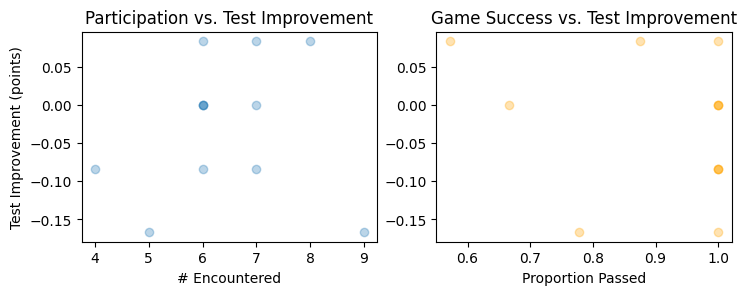

In [50]:
# H1 and H2 plots
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot, succPlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(aboveDF.puzzles_encountered, aboveDF.test_diff, alpha=0.3)
succPlot.scatter(aboveDF.proportion_passed, aboveDF.test_diff, c = 'orange', alpha=0.3)

#Formatting
partPlot.set_title('Participation vs. Test Improvement')
succPlot.set_title('Game Success vs. Test Improvement')
partPlot.set(xlabel='# Encountered')
partPlot.set(ylabel='Test Improvement (points)')
succPlot.set(xlabel='Proportion Passed')

#Show it
fig.show()

In [51]:
#H3 Stuff

<Figure size 640x480 with 0 Axes>

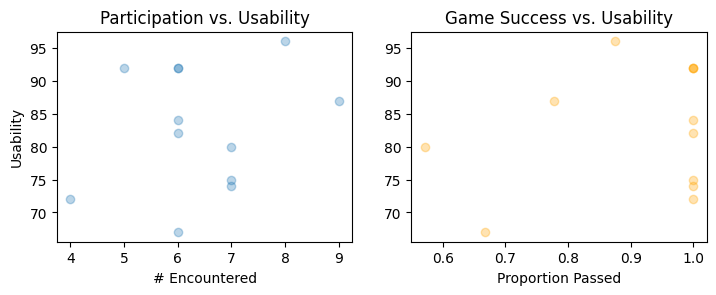

In [52]:
#H4 and H5 Stuff
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot, succPlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(aboveDF.puzzles_encountered, aboveDF.sentiment, alpha=0.3)
succPlot.scatter(aboveDF.proportion_passed, aboveDF.sentiment, c = 'orange', alpha=0.3)

#Formatting
partPlot.set_title('Participation vs. Usability')
succPlot.set_title('Game Success vs. Usability')
partPlot.set(xlabel='# Encountered')
partPlot.set(ylabel='Usability')
succPlot.set(xlabel='Proportion Passed')

#Show it
fig.show()

<Figure size 640x480 with 0 Axes>

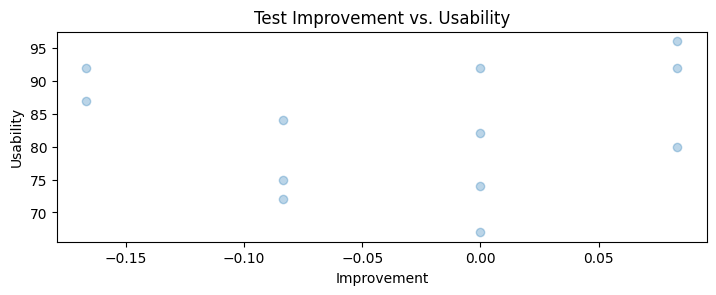

In [53]:
#H6 Stuff
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot) = plt.subplots(1, 1)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(aboveDF.test_diff, aboveDF.sentiment, alpha=0.3)

#Formatting
partPlot.set_title('Test Improvement vs. Usability')
partPlot.set(xlabel='Improvement')
partPlot.set(ylabel='Usability')

#Show it
fig.show()

# Correlation Below Median Pretest Score

In [54]:
import matplotlib.pyplot as plt

In [55]:
#Correlation matrix for all numerical data
median = summaryDF.pre_total.median() #We use median due to the skewed data
belowDF = summaryDF[summaryDF['pre_total'] <= median]
belowDF.corr(numeric_only=True)

,id,max_dif_beaten,puzzles_beaten,puzzles_failed,puzzles_encountered,proportion_passed,pre_total,post_total,test_diff,sentiment,usability_avg,use_avg,ease_avg
id,1.000000,-0.187596,-0.236087,0.257514,0.007012,-0.349674,0.209571,-0.171473,-0.311920,0.178252,0.178252,0.254667,0.058041
max_dif_beaten,-0.187596,1.000000,0.630946,-0.417555,0.160440,0.563277,-0.159965,0.370671,0.455585,0.528618,0.528618,0.310549,0.613465
puzzles_beaten,-0.236087,0.630946,1.000000,0.089776,0.751838,0.132169,0.142585,0.275821,0.143783,0.161898,0.161898,0.101846,0.181200
puzzles_failed,0.257514,-0.417555,0.089776,1.000000,0.724182,-0.955729,0.443357,-0.200610,-0.512803,-0.368555,-0.368555,-0.245438,-0.399007
puzzles_encountered,0.007012,0.160440,0.751838,0.724182,1.000000,-0.541198,0.392239,0.058172,-0.239930,-0.131892,-0.131892,-0.091966,-0.138687
proportion_passed,-0.349674,0.563277,0.132169,-0.955729,-0.541198,1.000000,-0.469870,0.256764,0.583522,0.433483,0.433483,0.280215,0.477698
pre_total,0.209571,-0.159965,0.142585,0.443357,0.392239,-0.469870,1.000000,0.280397,-0.491884,-0.248758,-0.248758,-0.093555,-0.340875
post_total,-0.171473,0.370671,0.275821,-0.200610,0.058172,0.256764,0.280397,1.000000,0.697811,0.080123,0.080123,0.095688,0.044732
test_diff,-0.311920,0.455585,0.143783,-0.512803,-0.239930,0.583522,-0.491884,0.697811,1.000000,0.258303,0.258303,0.156605,0.294941
sentiment,0.178252,0.528618,0.161898,-0.368555,-0.131892,0.433483,-0.248758,0.080123,0.258303,1.000000,1.000000,0.874059,0.876077


In [56]:
#Pearson correlations for relevant data
print('Sentiment vs. Encountered')
print(stats.pearsonr(belowDF['sentiment'], belowDF['puzzles_encountered']))

print('\nSentiment vs. Passed')
print(stats.pearsonr(belowDF['sentiment'], belowDF['proportion_passed']))

print('\nSentiment vs. Improvement')
print(stats.pearsonr(belowDF['sentiment'], belowDF['test_diff']))

print('\nImprovement vs. Encountered')
print(stats.pearsonr(belowDF['test_diff'], belowDF['puzzles_encountered']))

print('\nImprovement vs. Passed')
print(stats.pearsonr(belowDF['test_diff'], belowDF['proportion_passed']))

#Not related to hypotheses, but could still be handy
print('\nEncountered vs. Passed')
print(stats.pearsonr(belowDF['puzzles_encountered'], belowDF['proportion_passed']))

Sentiment vs. Encountered
PearsonRResult(statistic=np.float64(-0.13189203550500936), pvalue=np.float64(0.5904146395673344))

Sentiment vs. Passed
PearsonRResult(statistic=np.float64(0.43348321831056774), pvalue=np.float64(0.06372415572916652))

Sentiment vs. Improvement
PearsonRResult(statistic=np.float64(0.2583032245591672), pvalue=np.float64(0.2856406168184681))

Improvement vs. Encountered
PearsonRResult(statistic=np.float64(-0.23993037531015435), pvalue=np.float64(0.32247557062664495))

Improvement vs. Passed
PearsonRResult(statistic=np.float64(0.5835221115212357), pvalue=np.float64(0.008722431389157084))

Encountered vs. Passed
PearsonRResult(statistic=np.float64(-0.5411980276366297), pvalue=np.float64(0.016714382455920097))


<Figure size 640x480 with 0 Axes>

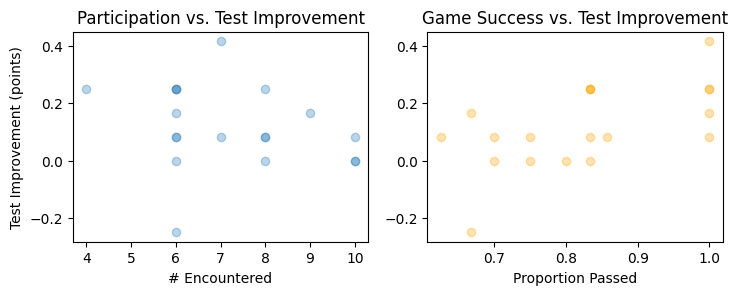

In [57]:
# H1 and H2 plots
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot, succPlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(belowDF.puzzles_encountered, belowDF.test_diff, alpha=0.3)
succPlot.scatter(belowDF.proportion_passed, belowDF.test_diff, c = 'orange', alpha=0.3)

#Formatting
partPlot.set_title('Participation vs. Test Improvement')
succPlot.set_title('Game Success vs. Test Improvement')
partPlot.set(xlabel='# Encountered')
partPlot.set(ylabel='Test Improvement (points)')
succPlot.set(xlabel='Proportion Passed')

#Show it
fig.show()

In [58]:
#H3 Stuff

<Figure size 640x480 with 0 Axes>

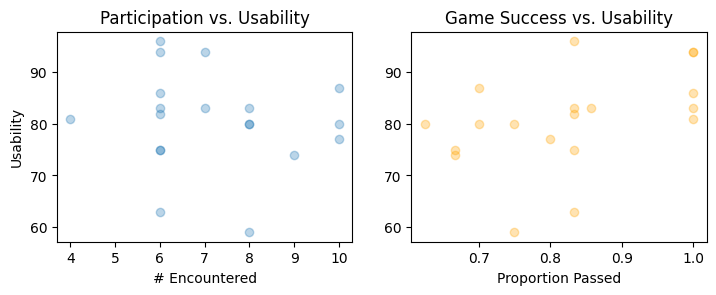

In [59]:
#H4 and H5 Stuff
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot, succPlot) = plt.subplots(1, 2)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(belowDF.puzzles_encountered, belowDF.sentiment, alpha=0.3)
succPlot.scatter(belowDF.proportion_passed, belowDF.sentiment, c = 'orange', alpha=0.3)

#Formatting
partPlot.set_title('Participation vs. Usability')
succPlot.set_title('Game Success vs. Usability')
partPlot.set(xlabel='# Encountered')
partPlot.set(ylabel='Usability')
succPlot.set(xlabel='Proportion Passed')

#Show it
fig.show()

<Figure size 640x480 with 0 Axes>

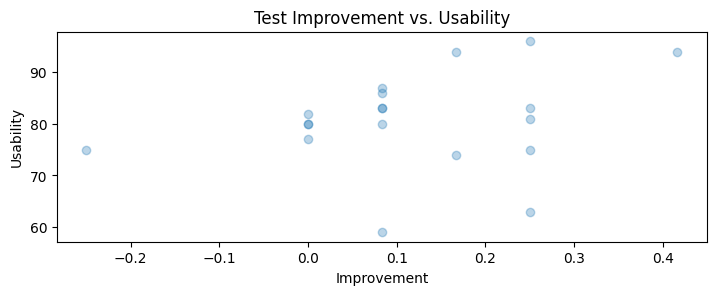

In [60]:
#H6 Stuff
#Make the overall figure and do some formatting
fig = plt.figure()
fig, (partPlot) = plt.subplots(1, 1)
fig.set_size_inches(6.5, 3)
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.20)

#Make the actual plots
partPlot.scatter(belowDF.test_diff, belowDF.sentiment, alpha=0.3)

#Formatting
partPlot.set_title('Test Improvement vs. Usability')
partPlot.set(xlabel='Improvement')
partPlot.set(ylabel='Usability')

#Show it
fig.show()

# T-Tests

In [61]:
import scipy.stats as stats

#First test to see if students did better post-game (table for 0.05 two-tailed with df=30 has a value of 2.042)
print(stats.ttest_rel(summaryDF.pre_total, summaryDF.post_total))
print('Pretest: avg={:.2f}, std={:.2f}'.format(summaryDF.pre_total.mean(), summaryDF.pre_total.std()))
print('Posttest: avg={:.2f}, std={:.2f}'.format(summaryDF.post_total.mean(), summaryDF.post_total.std()))

TtestResult(statistic=np.float64(-2.3858441924736833), pvalue=np.float64(0.023553533602709092), df=np.int64(30))
Pretest: avg=0.81, std=0.14
Posttest: avg=0.87, std=0.12


# T-Tests Above Median

In [62]:
import scipy.stats as stats

#First test to see if students did better post-game (table for 0.05 two-tailed with df=30 has a value of 2.042)
print(stats.ttest_rel(aboveDF.pre_total, aboveDF.post_total))
print('Pretest: avg={:.2f}, std={:.2f}'.format(aboveDF.pre_total.mean(), aboveDF.pre_total.std()))
print('Posttest: avg={:.2f}, std={:.2f}'.format(aboveDF.post_total.mean(), aboveDF.post_total.std()))

TtestResult(statistic=np.float64(1.07605517369794), pvalue=np.float64(0.30493723174143617), df=np.int64(11))
Pretest: avg=0.94, std=0.04
Posttest: avg=0.92, std=0.09


# T-Tests Below Median

In [63]:
import scipy.stats as stats

#First test to see if students did better post-game (table for 0.05 two-tailed with df=30 has a value of 2.042)
print(stats.ttest_rel(belowDF.pre_total, belowDF.post_total))
print('Pretest: avg={:.2f}, std={:.2f}'.format(belowDF.pre_total.mean(), belowDF.pre_total.std()))
print('Posttest: avg={:.2f}, std={:.2f}'.format(belowDF.post_total.mean(), belowDF.post_total.std()))

TtestResult(statistic=np.float64(-3.5555053785797908), pvalue=np.float64(0.0022601131953159273), df=np.int64(18))
Pretest: avg=0.72, std=0.11
Posttest: avg=0.84, std=0.13


# T-Test Comparing Sides of Median

In [64]:
print(stats.ttest_ind(aboveDF.test_diff, belowDF.test_diff, equal_var=False))
print('High scoring diff: avg={:.2f}, std={:.2f}'.format(aboveDF.test_diff.mean(), aboveDF.test_diff.std()))
print('Low scoring diff: avg={:.2f}, std={:.2f}'.format(belowDF.test_diff.mean(), belowDF.test_diff.std()))

TtestResult(statistic=np.float64(-3.4694360314494865), pvalue=np.float64(0.0016519017779617023), df=np.float64(28.997999698209107))
High scoring diff: avg=-0.03, std=0.09
Low scoring diff: avg=0.12, std=0.15


# Open-Ended Sentiment Analysis

In [65]:
#Load it into a dataframe
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

openEndedDF = pd.read_csv('drive/My Drive/Masters Stuff/Data Analysis/Raw CSVs/V2/survey_openended_breakdown.csv').fillna('None')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
#Count the occurences of each note
engagementDict = {}
troubleDict = {}
improvementDict = {}

#Engagement notes
for i, row in openEndedDF.iterrows():
  words = row['engagement_notes'].split(', ')
  for word in words:
    if word not in engagementDict:
      engagementDict[word] = 1
    else:
      engagementDict[word] += 1

#Trouble notes
for i, row in openEndedDF.iterrows():
  #Error check for 'none' rows
  if not isinstance(row['trouble_notes'], str):
    troubleDict['None'] += 1
    continue

  words = row['trouble_notes'].split(', ')
  for word in words:
    if word not in troubleDict:
      troubleDict[word] = 1
    else:
      troubleDict[word] += 1

#Improvement notes
for i, row in openEndedDF.iterrows():
  #Error check for 'none' rows
  if not isinstance(row['improvement_notes'], str):
    improvementDict['None'] += 1
    continue

  words = row['improvement_notes'].split(', ')
  for word in words:
    if word not in improvementDict:
      improvementDict[word] = 1
    else:
      improvementDict[word] += 1

#Sort them and display
engagementDict = dict(sorted(engagementDict.items(), key=lambda item: item[1], reverse=True))
troubleDict = dict(sorted(troubleDict.items(), key=lambda item: item[1], reverse=True))
improvementDict = dict(sorted(improvementDict.items(), key=lambda item: item[1], reverse=True))

print('---------Engagement Notes---------')
for key in engagementDict:
  print(key + ': ' + str(engagementDict[key]))

print('\n\n\n---------Trouble Notes---------')
for key in troubleDict:
  print(key + ': ' + str(troubleDict[key]))

print('\n\n\n---------Improvement Notes---------')
for key in improvementDict:
  print(key + ': ' + str(improvementDict[key]))

---------Engagement Notes---------
Did not answer: 6
Visuals: 4
Variation: 4
Characters: 3
None: 3
Guide: 2
Rewards: 2
Platforming: 2
Font: 2
Animations: 2
Different solutions: 1
Other games: 1
Text to speech: 1
Sound: 1
Exploration: 1



---------Trouble Notes---------
Not enough instruction: 7
Creating files: 6
Moving files: 4
Confusion: 3
File system: 3
None: 3
Did not answer: 2
Goal: 1
Pressing wrong things: 1
File names: 1
Deleting files: 1
Complicated: 1
Bugs: 1



---------Improvement Notes---------
Detailed instruction: 10
None: 8
Did not answer: 5
Hints: 3
Integrated tutorial: 2
Better names: 1
More challenge types: 1
Control display: 1
Easier navigation: 1


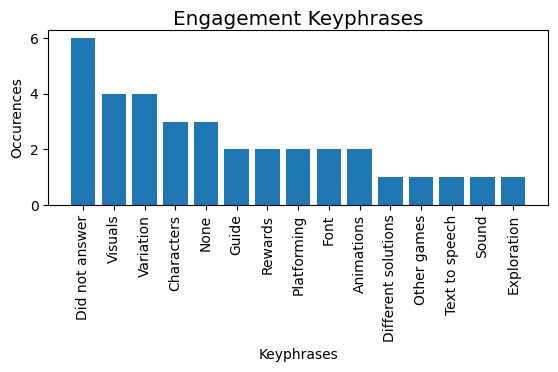

In [67]:
import matplotlib.pyplot as plt

#Histogram for the engagement notes
#Set up the figure
fig, plot = plt.subplots(1, 1)
fig.set_size_inches(5, 2.5)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.suptitle('Engagement Keyphrases', fontsize='x-large')
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.2)

#Do the actual plotting
plot.bar(engagementDict.keys(), engagementDict.values())

#Set up plot-specific stuff
plot.tick_params('x', labelrotation=90)
plot.set_xlabel('Keyphrases')
plot.set_ylabel('Occurences')

fig.show()

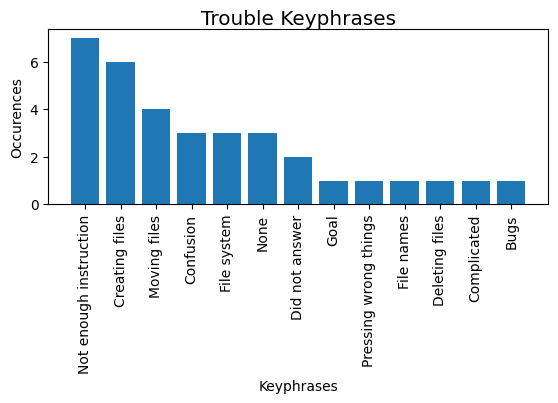

In [68]:
import matplotlib.pyplot as plt

#Histogram for the trouble notes
#Set up the figure
fig, plot = plt.subplots(1, 1)
fig.set_size_inches(5, 2.5)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.suptitle('Trouble Keyphrases', fontsize='x-large')
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.2)

#Do the actual plotting
plot.bar(troubleDict.keys(), troubleDict.values())

#Set up plot-specific stuff
plot.tick_params('x', labelrotation=90)
plot.set_xlabel('Keyphrases')
plot.set_ylabel('Occurences')

fig.show()

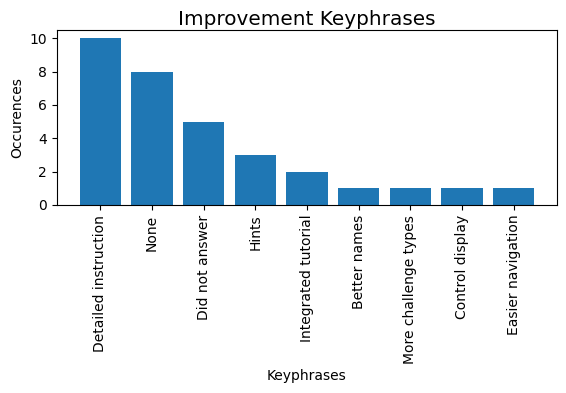

In [69]:
import matplotlib.pyplot as plt

#Histogram for the trouble notes
#Set up the figure
fig, plot = plt.subplots(1, 1)
fig.set_size_inches(5, 2.5)
fig.tight_layout(w_pad = 0, h_pad = 5)
fig.suptitle('Improvement Keyphrases', fontsize='x-large')
fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0.2)

#Do the actual plotting
plot.bar(improvementDict.keys(), improvementDict.values())

#Set up plot-specific stuff
plot.tick_params('x', labelrotation=90)
plot.set_xlabel('Keyphrases')
plot.set_ylabel('Occurences')

fig.show()

# Scratch

In [70]:
#Get some demographic intersections
hsurban = summaryDF[summaryDF['region'] == 'urban']
hsurban = hsurban[hsurban['grade'] == 'high']
print(hsurban)
msrural = summaryDF[summaryDF['region'] == 'rural']
msrural = msrural[msrural['grade'] == 'middle']
print(msrural)

Empty DataFrame
Columns: [id, max_dif_beaten, puzzles_beaten, puzzles_failed, date, puzzles_encountered, proportion_passed, pre_total, post_total, test_diff, sentiment, gender, grade, overall_hours, work_hours, game_hours, game_count, computer_access, region, usability_avg, use_avg, ease_avg]
Index: []

[0 rows x 22 columns]
          id  max_dif_beaten  puzzles_beaten  puzzles_failed        date  \
42567  42567             3.5               4               0  10/16/2024   

       puzzles_encountered  proportion_passed  pre_total  post_total  \
42567                    4                1.0        1.0    0.916667   

       test_diff  ...   grade overall_hours work_hours game_hours game_count  \
42567  -0.083333  ...  middle         15-30        2-5        2-5        0-1   

      computer_access region usability_avg use_avg  ease_avg  
42567               1  rural      3.428571     3.0       4.0  

[1 rows x 22 columns]


In [71]:
print(len(belowDF))

19


In [72]:
print(openEndedDF)

       id      engagement_notes                      trouble_notes  \
0   12111            Characters                    Confusion, Goal   
1   12316                 Guide             Not enough instruction   
2   13477        Did not answer                     Creating files   
3   13823   Different solutions                       Moving files   
4   15273                  None                     Creating files   
5   24457  Visuals, Other games              Pressing wrong things   
6   24648        Did not answer                         File names   
7   28651        Text to speech                        File system   
8   36577                  None                               None   
9   39316                 Guide                        File system   
10  41459            Characters             Not enough instruction   
11  42567               Rewards             Not enough instruction   
12  43268             Variation                       Moving files   
13  43933        Did

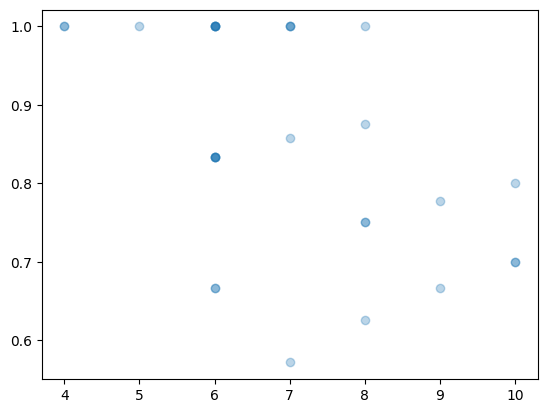

In [73]:
plt.scatter(summaryDF.puzzles_encountered, summaryDF.proportion_passed, alpha=0.3)